# Cuaderno 13 — LSTM con AumentO Temporal de Datos

## Motivación

El modelo LSTM del Cuaderno 07 alcanzó un MAPE OOS de **23.52%**, el peor
de todos los modelos del sistema. Su principal limitación radica en la escasez
de datos: con solo **51 meses** de serie (Oct 2021 – Dic 2025), el LSTM dispone
de apenas **~38 ventanas efectivas** de entrenamiento (`look_back=12`), muy por
debajo del mínimo recomendado de 500+ para redes profundas.

## Estrategia de Aumentación

Para abordar esta limitación, se emplea **aumentación temporal** mediante
descomposición STL (Seasonal-Trend decomposition using Loess):

| Componente | Período | Meses |
|-----------|---------|-------|
| **Backcast sintético** | Oct 2018 – Sep 2021 | 36 |
| **Serie real** | Oct 2021 – Dic 2025 | 51 |
| └ Entrenamiento | Oct 2018 – Sep 2025 | **84** |
| └ Prueba OOS | Oct – Dic 2025 | **3** |
| **Pronóstico extendido** | Ene 2026 – Dic 2030 | 60 |

### Impacto Esperado en Entrenamiento

| Métrica | Original (NB 07) | Aumentado (NB 13) | Cambio |
|---------|------------------|-------------------|--------|
| Meses entrenamiento | 48 | 84 | **+75%** |
| Ventanas efectivas | ~38 | ~71 | **+87%** |
| Ratio muestra/parámetro | ~0.0044 | ~0.0082 | **+86%** |

### Principio Metodológico

> La aumentación temporal genera **realizaciones sintéticas plausibles** del
> mismo proceso generador de datos, preservando la estacionalidad, tendencia
> y nivel de ruido observados. La evaluación OOS se realiza **exclusivamente
> sobre datos reales** (Oct–Dic 2025), garantizando la validez del benchmark.

---

In [1]:
%run 00_config.py

import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
import scipy.stats as stats

# ── Determinismo total ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.keras.utils.set_random_seed(SEED)

# ── Configuracion LSTM ──
LOOK_BACK = 12
FEATURE_COLS = ['y_log', 'Lag_1', 'IPC_Idx', 'Consumo_Hogares', 'UPC', 'SMLV_COP',
                'Mes_sin', 'Mes_cos', 'Es_Pico']
TARGET_COL = 'y_log'
EXOG_VARS = ['IPC_Idx', 'Consumo_Hogares', 'UPC', 'SMLV_COP']

# ── Macro historico pre-2021 (fuentes verificadas) ──
# IPC: DANE Boletin Tecnico IPC
# SMLV: Decretos presidenciales anuales
# UPC: Resoluciones MinSalud
# Consumo Hogares: Banco Mundial NE.CON.PRVT.KD.ZG
MACRO_HIST = {
    2018: {'IPC': 3.18, 'Salario_Minimo': 5.90, 'UPC': 8.00,
           'Consumo_Hogares': 3.20, 'Desempleo': 9.7, 'SMLV_COP': 781242},
    2019: {'IPC': 3.80, 'Salario_Minimo': 6.00, 'UPC': 10.00,
           'Consumo_Hogares': 2.50, 'Desempleo': 10.5, 'SMLV_COP': 828116},
    2020: {'IPC': 1.61, 'Salario_Minimo': 6.00, 'UPC': 6.00,
           'Consumo_Hogares': -6.00, 'Desempleo': 15.9, 'SMLV_COP': 877803},
}

# ── Proyecciones macro 2027-2030 (tendenciales) ──
MACRO_FWD = {
    2027: {'IPC': 4.80, 'Salario_Minimo': 8.00, 'UPC': 6.50,
           'Consumo_Hogares': 2.80, 'Desempleo': 9.0, 'SMLV_COP': 1890977},
    2028: {'IPC': 4.50, 'Salario_Minimo': 7.50, 'UPC': 6.00,
           'Consumo_Hogares': 3.00, 'Desempleo': 8.8, 'SMLV_COP': 2032800},
    2029: {'IPC': 4.20, 'Salario_Minimo': 7.00, 'UPC': 5.50,
           'Consumo_Hogares': 3.00, 'Desempleo': 8.5, 'SMLV_COP': 2175096},
    2030: {'IPC': 4.00, 'Salario_Minimo': 6.50, 'UPC': 5.00,
           'Consumo_Hogares': 3.20, 'Desempleo': 8.3, 'SMLV_COP': 2316477},
}

# Unificar todos los macros (IPC, UPC, Consumo_Hogares ya presentes)
MACRO_ALL = {}
MACRO_ALL.update(MACRO_HIST)
MACRO_ALL.update(MACRO_DATA)
MACRO_ALL.update(MACRO_FWD)

# SMLV_COP por ano (valores absolutos en COP)
SMLV_POR_ANO = {
    2018: 781242, 2019: 828116, 2020: 877803, 2021: 908526,
    2022: 1000000, 2023: 1160000, 2024: 1300000, 2025: 1423500,
    2026: 1750905, 2027: 1890977, 2028: 2032800, 2029: 2175096, 2030: 2316477,
}

print("=" * 60)
print("CONFIGURACION — LSTM CON AUMENTACION TEMPORAL")
print("=" * 60)
print(f"  SEED:        {SEED}")
print(f"  LOOK_BACK:   {LOOK_BACK}")
print(f"  Features:    {len(FEATURE_COLS)}")
print(f"  Macro hist:  {sorted(MACRO_HIST.keys())}")
print(f"  Macro fwd:   {sorted(MACRO_FWD.keys())}")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


CONFIGURACION — LSTM CON AUMENTACION TEMPORAL
  SEED:        42
  LOOK_BACK:   12
  Features:    9
  Macro hist:  [2018, 2019, 2020]
  Macro fwd:   [2027, 2028, 2029, 2030]


---

## Fase I — Descomposición STL de la Serie Original

### Metodología

La descomposición **STL** (Cleveland et al., 1990) descompone la serie en tres
componentes aditivos:

$$Y_t = T_t + S_t + R_t$$

donde:
- $T_t$: Tendencia (variación lenta de largo plazo)
- $S_t$: Estacionalidad (patrón cíclico de 12 meses)
- $R_t$: Residuo (variabilidad no explicada)

Estos componentes se extrapolan para generar el **backcast sintético**:
- **Tendencia**: Regresión lineal sobre $T_t$, proyectada hacia atrás
- **Estacionalidad**: Patrón mensual promedio (constante por mes)
- **Residuo**: $\mathcal{N}(0, \hat{\sigma}_R)$ — ruido calibrado

---

Serie original: 51 meses (Oct 2021 – Dec 2025)
  Rango: $162MM – $472MM

Descomposicion STL:
  Pendiente tendencia: $1.47MM COP/mes
  Desv. std residual:  $22.4MM COP
  R² tendencia:        0.9601

  Estacionalidad promedio por mes:
    Mes  1: $  +137.2MM ◄ PICO
    Mes  2: $   -31.2MM
    Mes  3: $   +33.1MM
    Mes  4: $   -74.5MM
    Mes  5: $   -72.0MM
    Mes  6: $   -36.1MM
    Mes  7: $  +114.4MM ◄ PICO
    Mes  8: $   -17.0MM
    Mes  9: $   -22.5MM
    Mes 10: $    +2.9MM
    Mes 11: $   -14.5MM
    Mes 12: $   -35.5MM


  📊 Figura guardada: 13_stl_decomposition.png


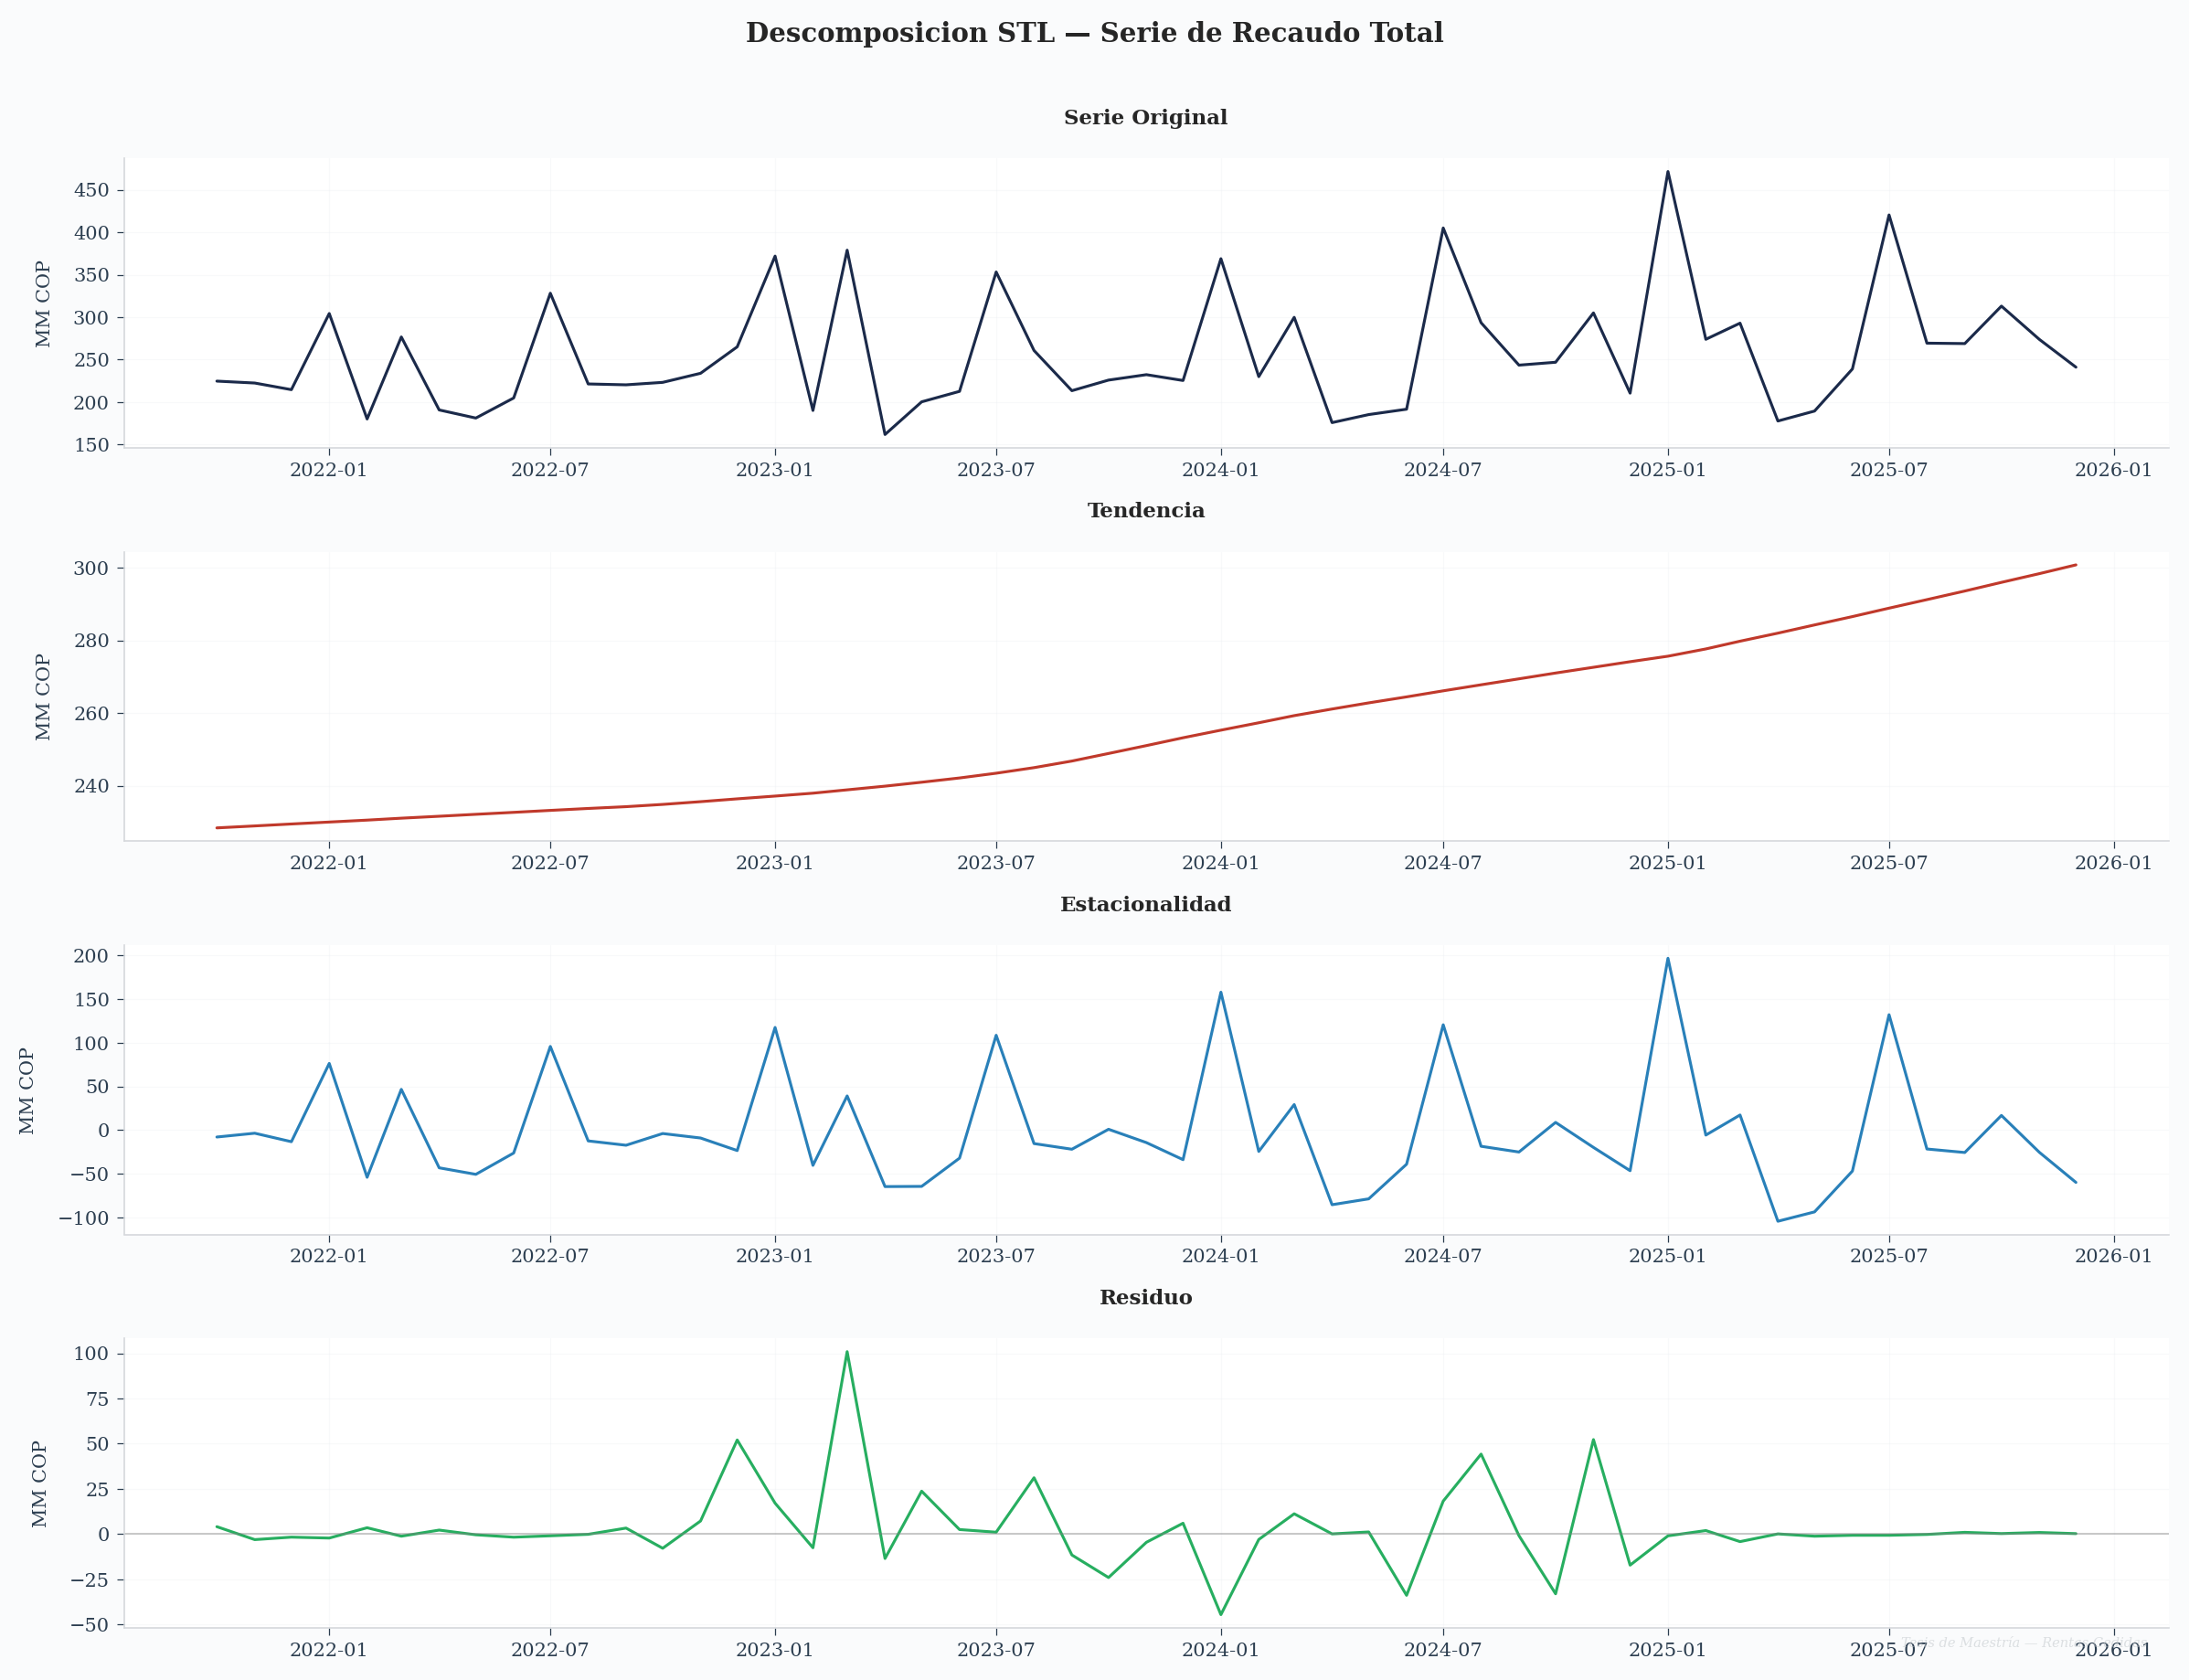

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE I — DESCOMPOSICION STL
# ══════════════════════════════════════════════════════════════

# -- Cargar serie real --
df_serie = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', parse_dates=['Fecha'])
df_serie = df_serie.set_index('Fecha').sort_index()
serie_full = df_serie['Recaudo_Total']

print(f"Serie original: {len(serie_full)} meses ({serie_full.index[0].strftime('%b %Y')} – {serie_full.index[-1].strftime('%b %Y')})")
print(f"  Rango: ${serie_full.min()/1e9:,.0f}MM – ${serie_full.max()/1e9:,.0f}MM")

# -- STL decomposition --
stl = STL(serie_full, period=12, robust=True)
res_stl = stl.fit()

# Extraer patron estacional promedio por mes calendario
seasonal_by_month = {}
for fecha, val in res_stl.seasonal.items():
    m = fecha.month
    if m not in seasonal_by_month:
        seasonal_by_month[m] = []
    seasonal_by_month[m].append(val)
seasonal_avg = {m: np.mean(vals) for m, vals in seasonal_by_month.items()}

# Ajustar tendencia lineal para extrapolacion
X_idx = np.arange(len(res_stl.trend)).reshape(-1, 1)
lr_trend = LinearRegression().fit(X_idx, res_stl.trend.values)
trend_slope = lr_trend.coef_[0]
trend_intercept = lr_trend.intercept_
residual_std = res_stl.resid.std()

print(f"\nDescomposicion STL:")
print(f"  Pendiente tendencia: ${trend_slope/1e9:,.2f}MM COP/mes")
print(f"  Desv. std residual:  ${residual_std/1e9:,.1f}MM COP")
print(f"  R² tendencia:        {lr_trend.score(X_idx, res_stl.trend.values):.4f}")

# Patron estacional por mes
print(f"\n  Estacionalidad promedio por mes:")
for m in range(1, 13):
    marker = ' ◄ PICO' if m in MESES_PICO else ''
    print(f"    Mes {m:2d}: ${seasonal_avg[m]/1e9:>+8.1f}MM{marker}")

# -- Visualizacion STL --
fig, axes = plt.subplots(4, 1, figsize=FIGSIZE_QUAD if _VIZ_THEME_LOADED else (16, 12))
comps = [('Serie Original', serie_full.values/1e9, C_PRIMARY),
         ('Tendencia', res_stl.trend.values/1e9, C_SECONDARY),
         ('Estacionalidad', res_stl.seasonal.values/1e9, C_TERTIARY),
         ('Residuo', res_stl.resid.values/1e9, C_QUATERNARY)]

for ax, (titulo, data, color) in zip(axes, comps):
    ax.plot(serie_full.index, data, color=color, linewidth=1.5)
    ax.set_ylabel('MM COP', fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if titulo == 'Residuo':
        ax.axhline(0, color='grey', linewidth=0.8, alpha=0.5)

fig.suptitle('Descomposicion STL — Serie de Recaudo Total', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '13_stl_decomposition', OUTPUTS_FIGURES)
plt.show()

---

## Fase II — Generación del Backcast Sintético

### Proceso de Síntesis (Oct 2018 – Sep 2021)

1. **Extrapolación de tendencia**: Regresión lineal ajustada sobre el componente
   de tendencia STL, proyectada 36 meses hacia atrás.
2. **Patrón estacional**: Valores promedio de $S_t$ por mes calendario,
   aplicados cíclicamente.
3. **Ruido calibrado**: $R_t^{sint} \sim \mathcal{N}(0, \hat{\sigma}_R)$
   con semilla fija para reproducibilidad.
4. **Variables macroeconómicas**: Valores históricos verificados (DANE, Banco
   Mundial, Decretos SMLV) para el período pre-2021.

### Control de Calidad
- **Piso mínimo**: 50 MM COP (ningún mes de recaudo puede ser menor)
- **Coherencia macro**: IPC_Idx encadenado hacia atrás desde 100 (Oct 2021)
- **SMLV_COP**: Valores históricos reales de decretos presidenciales

---

Backcast generado: 36 meses (Oct 2018 – Sep 2021)
  Rango: $90MM – $351MM
  Media: $187MM (real: $257MM)

Macro backcast:
  IPC_Idx:  90.12 (Oct 2018) → 99.53 (Sep 2021)
  SMLV:     $781,242 (2018) → $908,526 (2021)

Serie aumentada total: 87 meses (Oct 2018 – Dec 2025)


  📊 Figura guardada: 13_serie_aumentada.png


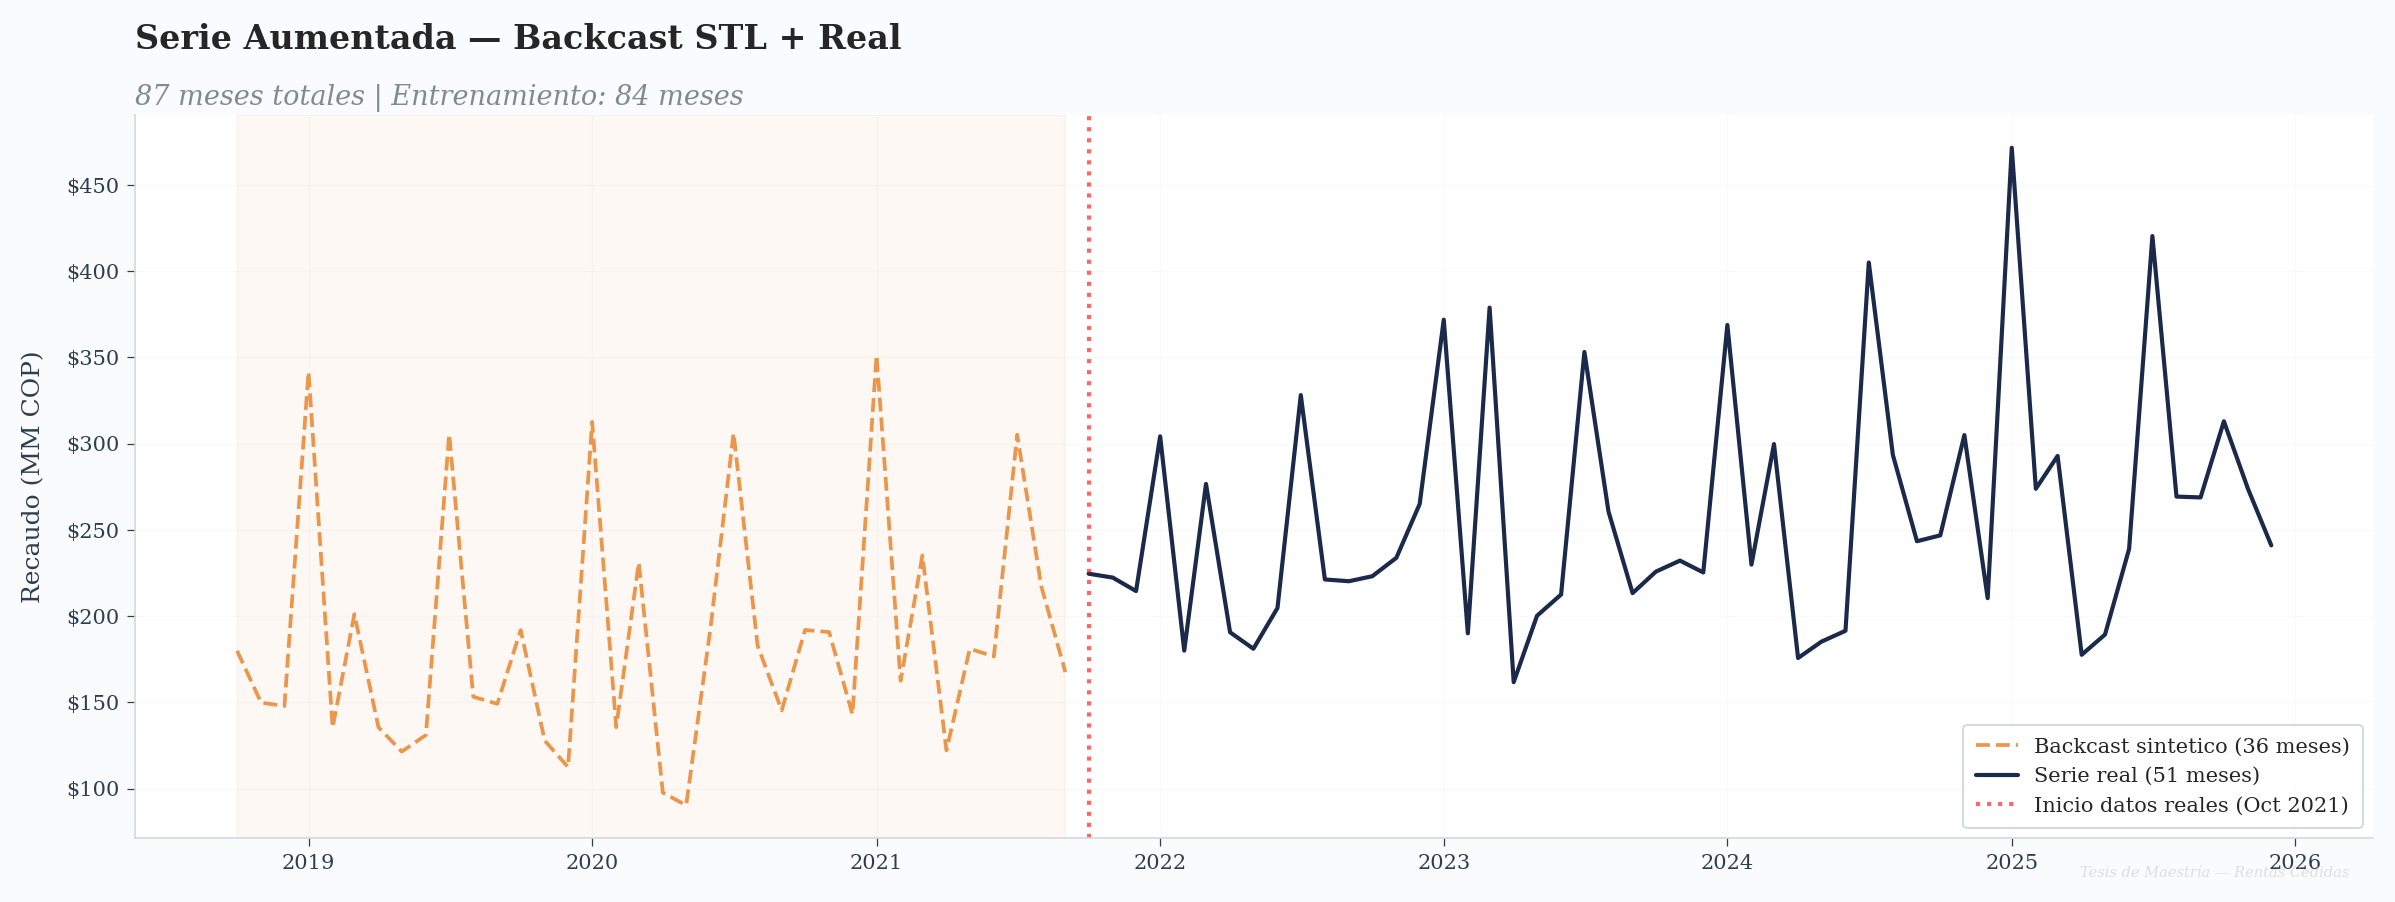

In [3]:
# ══════════════════════════════════════════════════════════════
# FASE II — GENERACION DEL BACKCAST SINTETICO
# ══════════════════════════════════════════════════════════════

# -- Generar backcast: Oct 2018 - Sep 2021 (36 meses) --
fechas_back = pd.date_range('2018-10-01', '2021-09-01', freq='MS')
n_back = len(fechas_back)

# Tendencia extrapolada (indices negativos = antes de Oct 2021)
back_indices = np.arange(-n_back, 0).reshape(-1, 1)
back_trend = lr_trend.predict(back_indices).flatten()

# Estacionalidad por mes calendario
back_seasonal = np.array([seasonal_avg[d.month] for d in fechas_back])

# Ruido calibrado
np.random.seed(SEED)
back_noise = np.random.normal(0, residual_std, n_back)

# Serie sintetica = tendencia + estacionalidad + ruido
back_values = back_trend + back_seasonal + back_noise

# Piso minimo: 50 MM COP
n_clipped = (back_values < 50e9).sum()
back_values = np.maximum(back_values, 50e9)
if n_clipped > 0:
    print(f"  ⚠ {n_clipped} valores sinteticos ajustados al piso de $50MM")

# DataFrame del backcast
df_backcast = pd.DataFrame({
    'Recaudo_Total': back_values,
}, index=fechas_back)
df_backcast.index.name = 'Fecha'

print(f"Backcast generado: {n_back} meses ({fechas_back[0].strftime('%b %Y')} – {fechas_back[-1].strftime('%b %Y')})")
print(f"  Rango: ${back_values.min()/1e9:,.0f}MM – ${back_values.max()/1e9:,.0f}MM")
print(f"  Media: ${back_values.mean()/1e9:,.0f}MM (real: ${serie_full.mean()/1e9:,.0f}MM)")

# ── Variables exogenas para el periodo de backcast ──

# 1. IPC_Idx: encadenar hacia atras desde 100 (Oct 2021)
ipc_back = []
current_ipc = 100.0
for fecha in reversed(fechas_back):
    yr = fecha.year
    rate = MACRO_ALL[yr]['IPC']
    current_ipc = current_ipc / (1 + rate / 100 / 12)
    ipc_back.append(current_ipc)
ipc_back = list(reversed(ipc_back))

# 2. SMLV_COP, Consumo_Hogares, UPC: por ano
smlv_back = [SMLV_POR_ANO[d.year] for d in fechas_back]
consumo_back = [MACRO_ALL[d.year]['Consumo_Hogares'] for d in fechas_back]
upc_back = [MACRO_ALL[d.year]['UPC'] for d in fechas_back]

df_macro_back = pd.DataFrame({
    'IPC_Idx': ipc_back,
    'Consumo_Hogares': consumo_back,
    'UPC': upc_back,
    'SMLV_COP': smlv_back,
}, index=fechas_back)
df_macro_back.index.name = 'Fecha'

print(f"\nMacro backcast:")
print(f"  IPC_Idx:  {ipc_back[0]:.2f} (Oct 2018) → {ipc_back[-1]:.2f} (Sep 2021)")
print(f"  SMLV:     ${smlv_back[0]:,.0f} (2018) → ${smlv_back[-1]:,.0f} (2021)")

# ── Ensamblar serie aumentada ──
# Real macro
df_macro_real = pd.read_csv(DATA_PROCESSED / 'serie_mensual_macro.csv', parse_dates=['Fecha'])
df_macro_real = df_macro_real.set_index('Fecha').sort_index()

# Concatenar backcast + real
serie_aug = pd.concat([df_backcast['Recaudo_Total'], serie_full])
macro_aug = pd.concat([df_macro_back[EXOG_VARS], df_macro_real[EXOG_VARS]])

print(f"\nSerie aumentada total: {len(serie_aug)} meses ({serie_aug.index[0].strftime('%b %Y')} – {serie_aug.index[-1].strftime('%b %Y')})")

# ── Visualizacion: serie aumentada vs real ──
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 7))

ax.plot(df_backcast.index, df_backcast['Recaudo_Total']/1e9,
        color=C_QUINARY, linewidth=1.8, linestyle='--', alpha=0.8,
        label=f'Backcast sintetico ({n_back} meses)')
ax.plot(serie_full.index, serie_full.values/1e9,
        color=C_PRIMARY, linewidth=2.0,
        label=f'Serie real ({len(serie_full)} meses)')
ax.axvline(serie_full.index[0], color='red', linestyle=':', alpha=0.6,
           label='Inicio datos reales (Oct 2021)')
ax.axvspan(df_backcast.index[0], df_backcast.index[-1],
           alpha=0.05, color=C_QUINARY)

ax.legend(fontsize=10)
ax.set_ylabel('Recaudo (MM COP)', fontsize=12)
ax.grid(True, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Serie Aumentada — Backcast STL + Real',
                       f'{len(serie_aug)} meses totales | Entrenamiento: 84 meses')
    formato_pesos_eje(ax, eje='y')
    marca_agua(fig)
    guardar_figura(fig, '13_serie_aumentada', OUTPUTS_FIGURES)
else:
    ax.set_title('Serie Aumentada — Backcast STL + Real', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Fase III — Feature Engineering sobre Serie Aumentada

Se aplican las **mismas transformaciones** que en el Cuaderno 07 para garantizar
comparación justa:

| Feature | Descripción | Fuente |
|---------|-------------|--------|
| `y_log` | $\log(1 + Y_t)$ — estabilización de varianza | Cálculo |
| `Lag_1` | Valor $y_{log}$ del mes anterior | Cálculo |
| `IPC_Idx` | Índice de precios acumulado | DANE / Sintético |
| `Consumo_Hogares` | Variación anual consumo hogares (%) | BM / Sintético |
| `UPC` | Variación anual UPC (%) | MinSalud / Sintético |
| `SMLV_COP` | Salario mínimo mensual (COP) | Decretos / Sintético |
| `Mes_sin`, `Mes_cos` | Codificación cíclica del mes | Cálculo |
| `Es_Pico` | Indicador meses pico (Ene, Jul) | Cálculo |

### Normalización
- `MinMaxScaler` ajustado **solo en datos de entrenamiento** (Oct 2018 – Sep 2025)
- Test (Oct–Dic 2025) transformado con el scaler ya ajustado (sin leakage)

---

In [4]:
# ══════════════════════════════════════════════════════════════
# FASE III — FEATURE ENGINEERING SOBRE SERIE AUMENTADA
# ══════════════════════════════════════════════════════════════

# -- Construir DataFrame de features --
df_model = pd.DataFrame({'Recaudo_Total': serie_aug}, index=serie_aug.index)

# Transformacion log1p
df_model['y_log'] = np.log1p(df_model['Recaudo_Total'])

# Lag_1
df_model['Lag_1'] = df_model['y_log'].shift(1)

# Exogenas macro
for col in EXOG_VARS:
    df_model[col] = macro_aug[col]

# Codificacion ciclica del mes
df_model['Mes_sin'] = np.sin(2 * np.pi * df_model.index.month / 12)
df_model['Mes_cos'] = np.cos(2 * np.pi * df_model.index.month / 12)

# Es_Pico (Enero=1, Julio=7)
df_model['Es_Pico'] = df_model.index.month.isin(MESES_PICO).astype(float)

# Eliminar fila con NaN del Lag_1 (primera fila: Oct 2018)
df_clean = df_model.dropna().copy()

print(f"Features construidos: {len(df_clean)} meses")
print(f"  Columnas: {list(df_clean.columns)}")
print(f"  Rango: {df_clean.index[0].strftime('%b %Y')} – {df_clean.index[-1].strftime('%b %Y')}")

# -- Train/Test split (mismo punto de corte que NB 07) --
df_train = df_clean[df_clean.index <= pd.Timestamp(TRAIN_END)]
df_test = df_clean[df_clean.index >= pd.Timestamp(TEST_START)]

print(f"\n  Train: {len(df_train)} meses ({df_train.index[0].strftime('%b %Y')} – {df_train.index[-1].strftime('%b %Y')})")
print(f"  Test:  {len(df_test)} meses ({df_test.index[0].strftime('%b %Y')} – {df_test.index[-1].strftime('%b %Y')})")

# -- Normalizar --
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

train_X_vals = df_train[FEATURE_COLS].values
train_y_vals = df_train[[TARGET_COL]].values

scaler_X.fit(train_X_vals)
scaler_y.fit(train_y_vals)

# Transformar toda la serie
all_X_scaled = scaler_X.transform(df_clean[FEATURE_COLS].values)
all_y_scaled = scaler_y.transform(df_clean[[TARGET_COL]].values)

n_features = len(FEATURE_COLS)
print(f"\n  Scaler X fit en {len(train_X_vals)} muestras ({n_features} features)")
print(f"  Scaler y fit en {len(train_y_vals)} muestras")

# -- Windowing --
def crear_ventanas(X_data, y_data, look_back):
    Xs, ys = [], []
    for i in range(look_back, len(X_data)):
        Xs.append(X_data[i - look_back:i])
        ys.append(y_data[i])
    return np.array(Xs), np.array(ys)

# Ventanas de toda la serie (backcast + real)
X_all_seq, y_all_seq = crear_ventanas(all_X_scaled, all_y_scaled.flatten(), LOOK_BACK)

# Indice temporal para separar train/test
n_total = len(df_clean)
n_train = len(df_train)
n_test = len(df_test)

# Las ventanas de entrenamiento: las primeras (n_train - LOOK_BACK)
# Las ventanas de test: las ultimas n_test
split_idx = n_train - LOOK_BACK
X_train_seq = X_all_seq[:split_idx]
y_train_seq = y_all_seq[:split_idx]
X_test_seq = X_all_seq[split_idx:]
y_test_seq = y_all_seq[split_idx:]

print(f"\n  Ventanas de entrenamiento: {len(X_train_seq)} (vs ~38 en NB 07)")
print(f"  Ventanas de prueba:        {len(X_test_seq)}")
print(f"  Shape X_train: {X_train_seq.shape}")
print(f"  Shape X_test:  {X_test_seq.shape}")
print(f"  Mejora: {len(X_train_seq)/38:.1f}x mas ventanas que el modelo original")

Features construidos: 86 meses
  Columnas: ['Recaudo_Total', 'y_log', 'Lag_1', 'IPC_Idx', 'Consumo_Hogares', 'UPC', 'SMLV_COP', 'Mes_sin', 'Mes_cos', 'Es_Pico']
  Rango: Nov 2018 – Dec 2025

  Train: 83 meses (Nov 2018 – Sep 2025)
  Test:  3 meses (Oct 2025 – Dec 2025)

  Scaler X fit en 83 muestras (9 features)
  Scaler y fit en 83 muestras

  Ventanas de entrenamiento: 71 (vs ~38 en NB 07)
  Ventanas de prueba:        3
  Shape X_train: (71, 12, 9)
  Shape X_test:  (3, 12, 9)
  Mejora: 1.9x mas ventanas que el modelo original


---

## Fase IV — Arquitectura y Entrenamiento LSTM

### Arquitectura Idéntica al Cuaderno 07

Para garantizar una comparación justa, se utiliza **exactamente la misma
arquitectura** del LSTM original:

```
Input(12, 9) → LSTM(64, L2) → Dropout(0.2) → LSTM(32, L2) → Dropout(0.2) → Dense(16, ReLU) → Dense(1)
```

| Parámetro | Valor |
|-----------|-------|
| Look-back | 12 meses |
| Capas LSTM | 64 → 32 unidades |
| Regularización | L2(0.001) + Dropout(0.2) |
| Optimizer | Adam (lr=0.001) |
| Batch size | 4 |
| Early Stopping | patience=30 |
| ReduceLR | patience=15, factor=0.5 |

### Única Diferencia: Volumen de Datos

La **única variable experimental** es el tamaño del conjunto de entrenamiento:
~71 ventanas (aumentado) vs ~38 ventanas (original).

---

Arquitectura LSTM (identica a NB 07):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

...


Epoch 122: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


Epoch 122: early stopping


Restoring model weights from the end of the best epoch: 92.



  Entrenamiento completado en 40.2 seg
  Epocas: 122/500
  Mejor epoca: 92
  Loss final (train): 0.015974
  Loss final (val):   0.024179


  📊 Figura guardada: 13_lstm_aug_curvas_aprendizaje.png


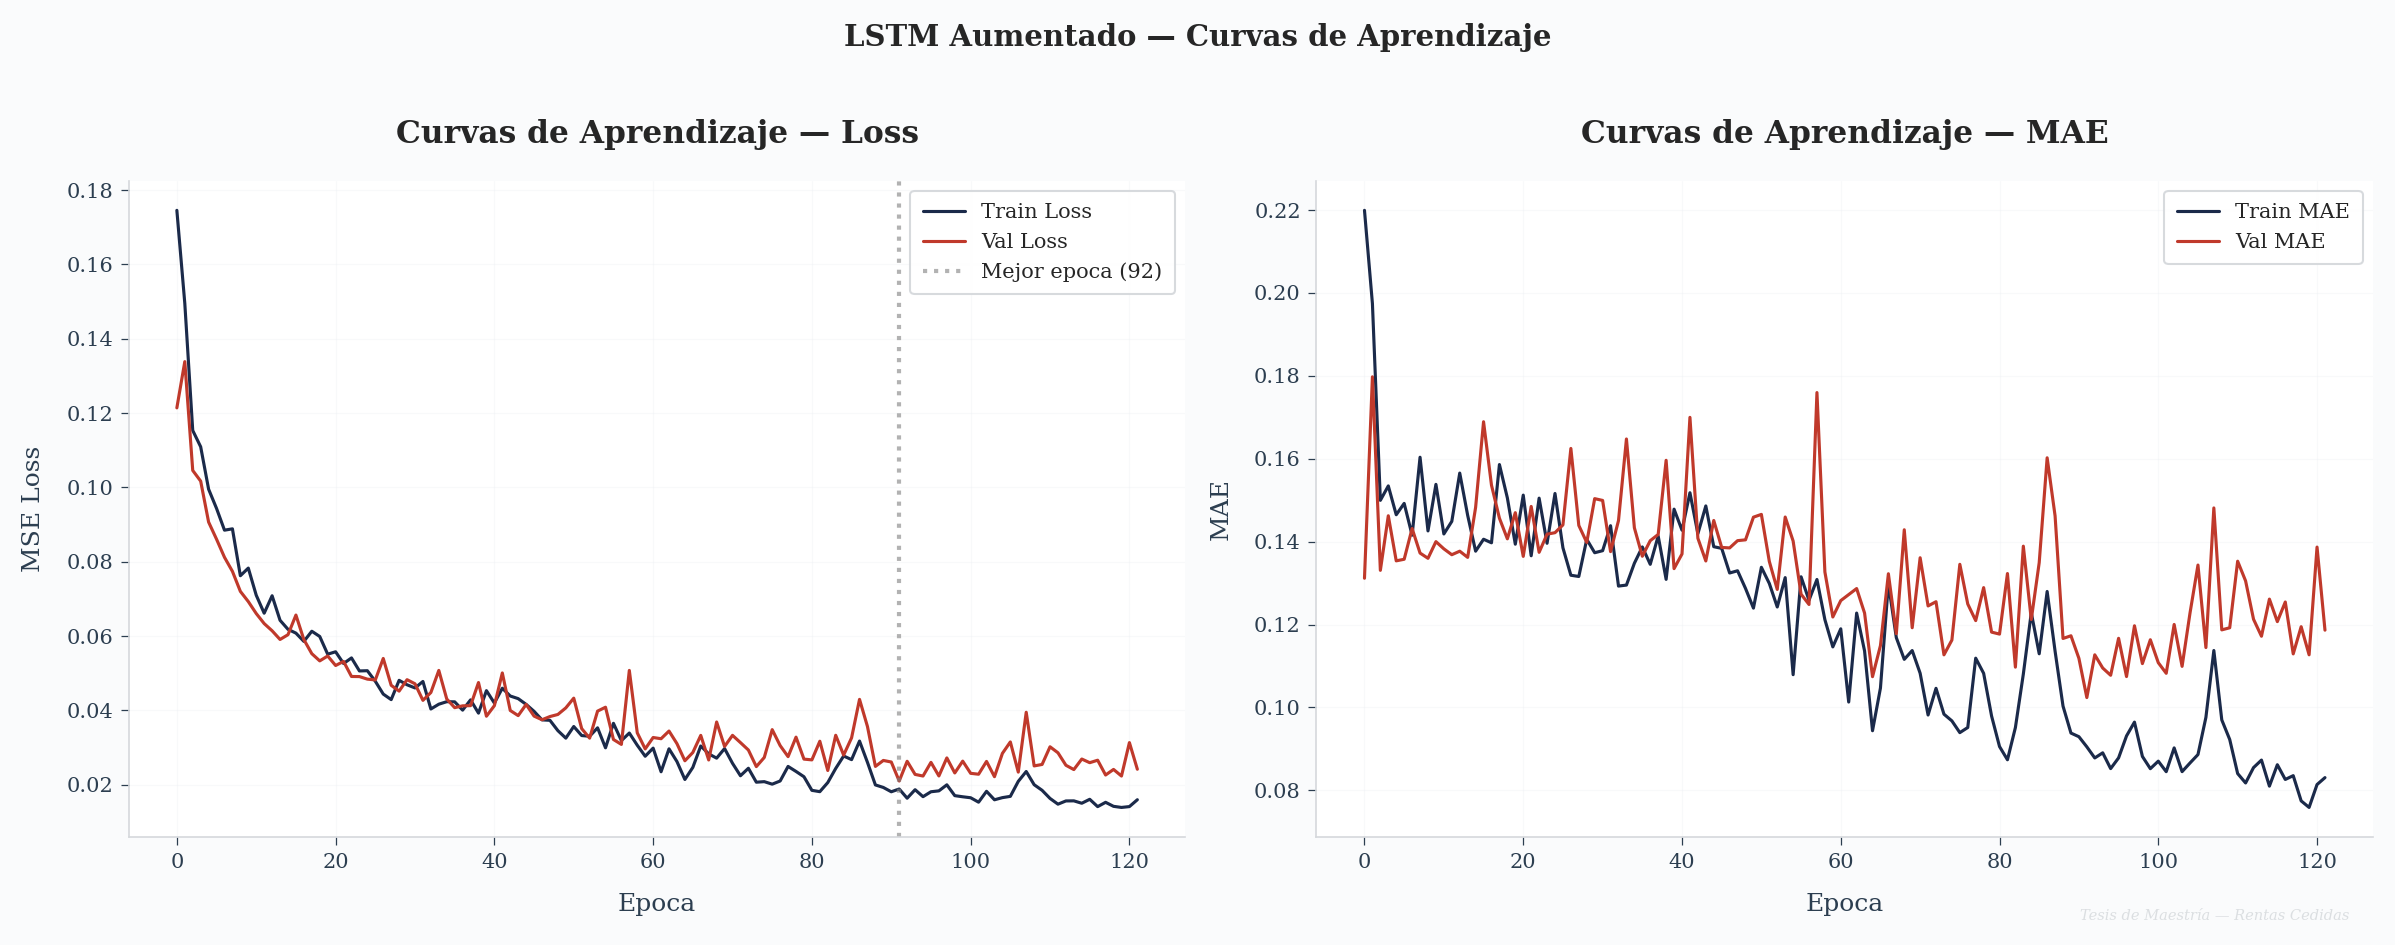

In [5]:
# ══════════════════════════════════════════════════════════════
# FASE IV — ARQUITECTURA Y ENTRENAMIENTO LSTM
# ══════════════════════════════════════════════════════════════

model = Sequential([
    Input(shape=(LOOK_BACK, n_features)),
    LSTM(64, return_sequences=True,
         kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.2),
    LSTM(32, return_sequences=False,
         kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear'),
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

n_params = model.count_params()
ratio = len(X_train_seq) / n_params

print("Arquitectura LSTM (identica a NB 07):")
model.summary()
print(f"\n  Parametros totales: {n_params:,}")
print(f"  Muestras train:    {len(X_train_seq)}")
print(f"  Ratio muestras/params: {ratio:.4f} (vs ~0.0044 original)")

# -- Callbacks --
early_stop = EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True,
    verbose=1, mode='min',
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', patience=15, factor=0.5,
    min_lr=1e-6, verbose=1, mode='min',
)

# -- Entrenamiento --
print(f"\nEntrenando LSTM con {len(X_train_seq)} muestras...")
t0 = time.time()

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=500,
    batch_size=4,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=0,
    shuffle=False,
)

elapsed = time.time() - t0
n_epochs = len(history.history['loss'])
best_epoch = np.argmin(history.history['val_loss']) + 1

print(f"\n  Entrenamiento completado en {elapsed:.1f} seg")
print(f"  Epocas: {n_epochs}/500")
print(f"  Mejor epoca: {best_epoch}")
print(f"  Loss final (train): {history.history['loss'][-1]:.6f}")
print(f"  Loss final (val):   {history.history['val_loss'][-1]:.6f}")

# -- Curvas de aprendizaje --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 6))

ax1.plot(history.history['loss'], color=C_PRIMARY, label='Train Loss', linewidth=1.5)
ax1.plot(history.history['val_loss'], color=C_SECONDARY, label='Val Loss', linewidth=1.5)
ax1.axvline(best_epoch - 1, color='grey', linestyle=':', alpha=0.6, label=f'Mejor epoca ({best_epoch})')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Curvas de Aprendizaje — Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'], color=C_PRIMARY, label='Train MAE', linewidth=1.5)
ax2.plot(history.history['val_mae'], color=C_SECONDARY, label='Val MAE', linewidth=1.5)
ax2.set_xlabel('Epoca')
ax2.set_ylabel('MAE')
ax2.set_title('Curvas de Aprendizaje — MAE', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('LSTM Aumentado — Curvas de Aprendizaje', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '13_lstm_aug_curvas_aprendizaje', OUTPUTS_FIGURES)
plt.show()

---

## Fase V — Evaluación Out-of-Sample (Datos Reales Oct–Dic 2025)

### MC Dropout para Intervalos de Confianza

Se ejecutan **200 pasadas** con Dropout activo durante inferencia (Gal &
Ghahramani, 2016). La distribución de predicciones aproxima una distribución
posterior bayesiana, generando intervalos de confianza al 95%.

### Cadena de Retransformación

```
Predicción escalada → inverse_scaler → y_log → expm1 → Pesos COP
```

### Evaluación sobre Datos Reales

La evaluación se realiza **exclusivamente** sobre los 3 meses de datos reales
(Oct–Dic 2025), independientemente de los datos sintéticos usados en entrenamiento.

---

EVALUACION OOS — LSTM AUMENTADO
  2025-10  Real: $   313.0MM  Pred: $   294.0MM  Error: 6.1%  [$244.7 – $340.4]
  2025-11  Real: $   273.8MM  Pred: $   319.6MM  Error: 16.7%  [$251.4 – $379.3]
  2025-12  Real: $   241.0MM  Pred: $   355.7MM  Error: 47.6%  [$272.9 – $433.2]

──────────────────────────────────────────────────────────────────────
  MAPE:    23.45%
  RMSE:    $72.1 MM COP
  MAE:     $59.8 MM COP
  MAE rel: 21.7%

  Forecast OOS exportado: lstm_augmented_forecast.csv


  📊 Figura guardada: 13_lstm_aug_prediccion_oos.png


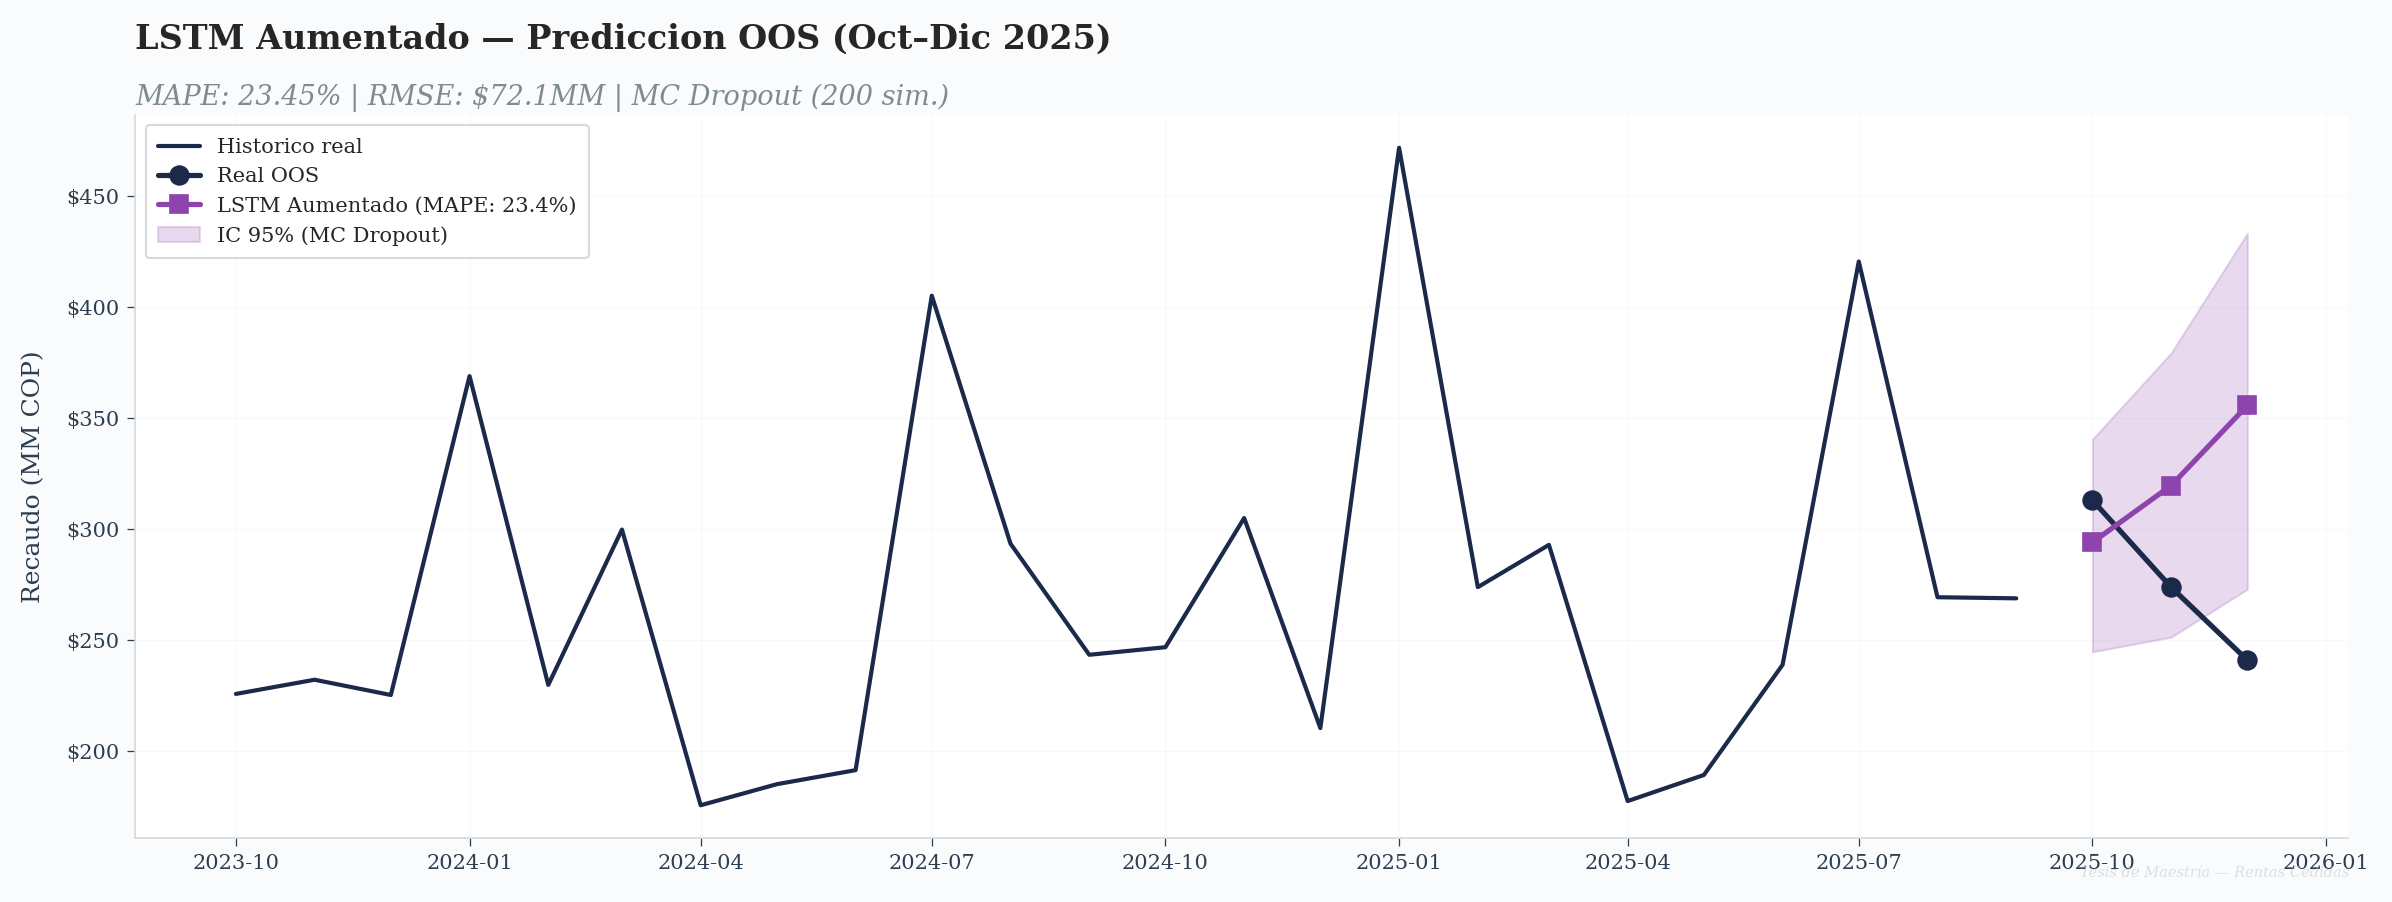

In [6]:
# ══════════════════════════════════════════════════════════════
# FASE V — EVALUACION OUT-OF-SAMPLE
# ══════════════════════════════════════════════════════════════

N_MC = 200

# MC Dropout: multiples pasadas con Dropout activo
mc_preds_scaled = np.array([
    model(X_test_seq, training=True).numpy().flatten()
    for _ in range(N_MC)
])

# Retransformar a escala original
mc_preds_log = np.array([
    scaler_y.inverse_transform(pred.reshape(-1, 1)).flatten()
    for pred in mc_preds_scaled
])
mc_preds_pesos = np.expm1(mc_preds_log)

# Pronostico puntual: media de MC
pred_mean_log = mc_preds_log.mean(axis=0)
pred_mean_pesos = np.expm1(pred_mean_log)

# IC 95%
ci_low = np.maximum(0, np.percentile(mc_preds_pesos, 2.5, axis=0))
ci_high = np.percentile(mc_preds_pesos, 97.5, axis=0)

# Valores reales
y_real_log = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
y_real_pesos = np.expm1(y_real_log)

# Metricas
errors = np.abs(y_real_pesos - pred_mean_pesos)
pct_errors = errors / y_real_pesos * 100
mape = pct_errors.mean()
rmse = np.sqrt(np.mean((y_real_pesos - pred_mean_pesos)**2))
mae = errors.mean()
mae_rel = mae / y_real_pesos.mean() * 100

print("=" * 70)
print("EVALUACION OOS — LSTM AUMENTADO")
print("=" * 70)

fechas_test = df_test.index
for i, fecha in enumerate(fechas_test):
    real = y_real_pesos[i]
    pred = pred_mean_pesos[i]
    err = pct_errors[i]
    print(f"  {fecha.strftime('%Y-%m')}  Real: ${real/1e9:>8.1f}MM  "
          f"Pred: ${pred/1e9:>8.1f}MM  Error: {err:.1f}%  "
          f"[${ci_low[i]/1e9:.1f} – ${ci_high[i]/1e9:.1f}]")

print(f"\n{'─'*70}")
print(f"  MAPE:    {mape:.2f}%")
print(f"  RMSE:    ${rmse/1e9:,.1f} MM COP")
print(f"  MAE:     ${mae/1e9:,.1f} MM COP")
print(f"  MAE rel: {mae_rel:.1f}%")

# -- Guardar forecast OOS --
df_forecast_aug = pd.DataFrame({
    'Fecha': fechas_test,
    'Real': y_real_pesos,
    'Pronostico_LSTM_Aug': pred_mean_pesos,
    'IC_Inferior': ci_low,
    'IC_Superior': ci_high,
    'Error_Abs': errors,
    'Error_Pct': pct_errors,
})
df_forecast_aug.to_csv(OUTPUTS_FORECASTS / 'lstm_augmented_forecast.csv', index=False)
print(f"\n  Forecast OOS exportado: lstm_augmented_forecast.csv")

# -- Grafica OOS --
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 7))

# Historico real (ultimos 24 meses para contexto)
hist_start = fechas_test[0] - pd.DateOffset(months=24)
mask_hist = (serie_full.index >= hist_start) & (serie_full.index < fechas_test[0])
ax.plot(serie_full.index[mask_hist], serie_full.values[mask_hist]/1e9,
        color=C_PRIMARY, linewidth=2, label='Historico real')

ax.plot(fechas_test, y_real_pesos/1e9, 'o-', color=C_PRIMARY,
        linewidth=2.5, markersize=9, label='Real OOS', zorder=5)
ax.plot(fechas_test, pred_mean_pesos/1e9, 's-', color=C_SENARY,
        linewidth=2.5, markersize=9, label=f'LSTM Aumentado (MAPE: {mape:.1f}%)', zorder=5)
ax.fill_between(fechas_test, ci_low/1e9, ci_high/1e9,
                alpha=0.20, color=C_SENARY, label='IC 95% (MC Dropout)')

ax.legend(fontsize=10)
ax.set_ylabel('Recaudo (MM COP)', fontsize=12)
ax.grid(True, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'LSTM Aumentado — Prediccion OOS (Oct–Dic 2025)',
                       f'MAPE: {mape:.2f}% | RMSE: ${rmse/1e9:,.1f}MM | MC Dropout ({N_MC} sim.)')
    formato_pesos_eje(ax, eje='y')
    marca_agua(fig)
    guardar_figura(fig, '13_lstm_aug_prediccion_oos', OUTPUTS_FIGURES)
else:
    ax.set_title(f'LSTM Aumentado — Prediccion OOS (MAPE: {mape:.2f}%)',
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Fase VI — Comparación: LSTM Original vs LSTM Aumentado

### Diseño Experimental
- **Variable controlada**: Arquitectura de red (idéntica en ambos)
- **Variable experimental**: Tamaño del conjunto de entrenamiento
- **Original (NB 07)**: ~38 ventanas (48 meses reales)
- **Aumentado (NB 13)**: ~71 ventanas (84 meses: 36 sintéticos + 48 reales)
- **Evaluación**: Mismos 3 meses OOS reales (Oct–Dic 2025)

---

COMPARACION: LSTM ORIGINAL vs LSTM AUMENTADO

  Metrica                 Original (NB07)   Aumentado (NB13)       Mejora
  ────────────────────────────────────────────────────────────────────
  MAPE (%)                         23.52%             23.45%       +0.07pp
  RMSE (MM COP)                     $73.5              $72.1       +1.9%
  MAE (MM COP)                      $59.6              $59.8       -0.3%

  Ventanas train                      ~38                ~71          +33
  Meses train                          48                 84          +36

  Detalle mes a mes:
  Mes                Real     Original    Aumentado   Err Orig    Err Aug
  ──────────────────────────────────────────────────────────────────
  2025-10    $    313.0MM $    318.1MM $    294.0MM      1.6%      6.1%
  2025-11    $    273.8MM $    337.2MM $    319.6MM     23.2%     16.7%
  2025-12    $    241.0MM $    351.4MM $    355.7MM     45.8%     47.6%


  📊 Figura guardada: 13_lstm_original_vs_aumentado.png


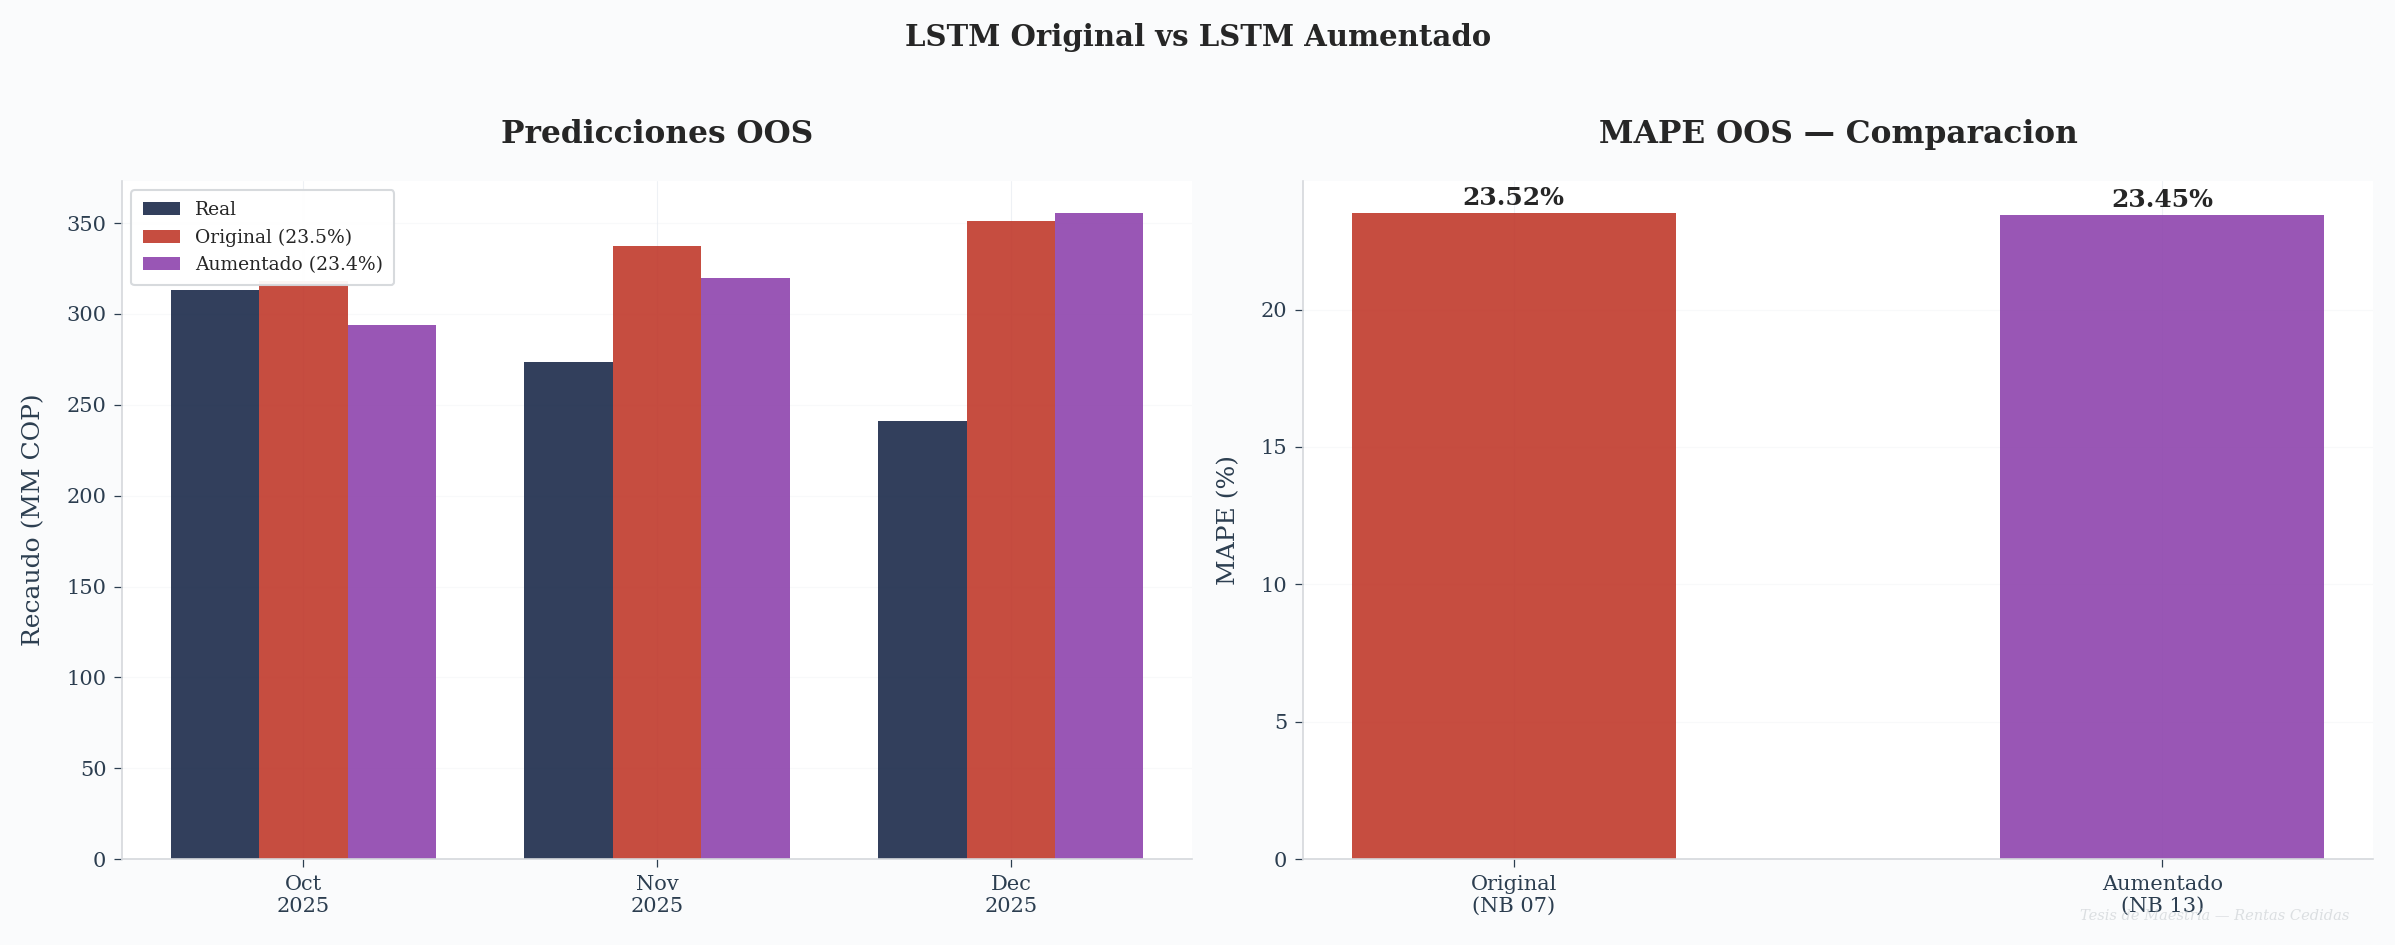


  VEREDICTO: MEJORA DE 0.07pp EN MAPE


In [7]:
# ══════════════════════════════════════════════════════════════
# FASE VI — COMPARACION LSTM ORIGINAL vs AUMENTADO
# ══════════════════════════════════════════════════════════════

# -- Cargar forecast del LSTM original --
df_orig = pd.read_csv(OUTPUTS_FORECASTS / 'lstm_forecast.csv')
df_orig['Fecha'] = pd.to_datetime(df_orig['Fecha'])

# Extraer metricas del original
orig_errors_pct = df_orig['Error_Pct'].values
orig_mape = orig_errors_pct.mean()
orig_rmse = np.sqrt(np.mean(df_orig['Error_Abs'].values**2))
orig_mae = df_orig['Error_Abs'].mean()

print("=" * 70)
print("COMPARACION: LSTM ORIGINAL vs LSTM AUMENTADO")
print("=" * 70)
print(f"\n  {'Metrica':<20} {'Original (NB07)':>18} {'Aumentado (NB13)':>18} {'Mejora':>12}")
print(f"  {'─'*68}")

# MAPE
mejora_mape = orig_mape - mape
print(f"  {'MAPE (%)' :<20} {orig_mape:>17.2f}% {mape:>17.2f}% {mejora_mape:>+11.2f}pp")

# RMSE
mejora_rmse = (orig_rmse - rmse) / orig_rmse * 100
print(f"  {'RMSE (MM COP)':<20} {'${:,.1f}'.format(orig_rmse/1e9):>18} {'${:,.1f}'.format(rmse/1e9):>18} {mejora_rmse:>+10.1f}%")

# MAE
mejora_mae = (orig_mae - mae) / orig_mae * 100
print(f"  {'MAE (MM COP)':<20} {'${:,.1f}'.format(orig_mae/1e9):>18} {'${:,.1f}'.format(mae/1e9):>18} {mejora_mae:>+10.1f}%")

# Ventanas
print(f"\n  {'Ventanas train':<20} {'~38':>18} {f'~{len(X_train_seq)}':>18} {f'+{len(X_train_seq)-38}':>12}")
print(f"  {'Meses train':<20} {'48':>18} {'84':>18} {'+36':>12}")

# -- Detalle mes a mes --
print(f"\n  Detalle mes a mes:")
print(f"  {'Mes':<10} {'Real':>12} {'Original':>12} {'Aumentado':>12} {'Err Orig':>10} {'Err Aug':>10}")
print(f"  {'─'*66}")
for i, fecha in enumerate(fechas_test):
    real = y_real_pesos[i]
    orig_pred = df_orig[df_orig['Fecha'] == fecha]['Pronostico_LSTM'].values
    aug_pred = pred_mean_pesos[i]
    if len(orig_pred) > 0:
        orig_p = orig_pred[0]
        print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>9.1f}MM ${orig_p/1e9:>9.1f}MM ${aug_pred/1e9:>9.1f}MM "
              f"{abs(real-orig_p)/real*100:>8.1f}% {pct_errors[i]:>8.1f}%")

# -- Grafica comparativa --
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 7))

# Panel 1: Predicciones comparadas
ax = axes[0]
x_pos = np.arange(len(fechas_test))
width = 0.25
ax.bar(x_pos - width, y_real_pesos/1e9, width, color=C_PRIMARY, label='Real', alpha=0.9)
if len(df_orig) >= len(fechas_test):
    orig_vals = df_orig['Pronostico_LSTM'].values[:len(fechas_test)]
    ax.bar(x_pos, orig_vals/1e9, width, color=C_SECONDARY, label=f'Original ({orig_mape:.1f}%)', alpha=0.9)
ax.bar(x_pos + width, pred_mean_pesos/1e9, width, color=C_SENARY, label=f'Aumentado ({mape:.1f}%)', alpha=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels([f.strftime('%b\n%Y') for f in fechas_test])
ax.set_ylabel('Recaudo (MM COP)')
ax.set_title('Predicciones OOS', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Panel 2: Errores porcentuales
ax = axes[1]
modelos = ['Original\n(NB 07)', 'Aumentado\n(NB 13)']
mapes = [orig_mape, mape]
colores = [C_SECONDARY, C_SENARY]
bars = ax.bar(modelos, mapes, color=colores, alpha=0.9, width=0.5)
for bar, val in zip(bars, mapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE OOS — Comparacion', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('LSTM Original vs LSTM Aumentado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '13_lstm_original_vs_aumentado', OUTPUTS_FIGURES)
plt.show()

# Veredicto
if mape < orig_mape:
    veredicto = f"MEJORA DE {orig_mape - mape:.2f}pp EN MAPE"
else:
    veredicto = f"SIN MEJORA SIGNIFICATIVA (diferencia: {mape - orig_mape:.2f}pp)"
print(f"\n  VEREDICTO: {veredicto}")

---

## Fase VII — Diagnóstico de Residuos

Se aplican las mismas **4 pruebas estadísticas** que en el Cuaderno 07:

| Prueba | Hipótesis | Umbral |
|--------|-----------|--------|
| Ljung-Box | No autocorrelación residual | $p > 0.05$ |
| Shapiro-Wilk | Normalidad de residuos | $p > 0.05$ |
| t-test ($\mu=0$) | Media cero (no sesgo) | $p > 0.05$ |
| Levene | Homocedasticidad | $p > 0.05$ |

---

DIAGNOSTICO DE RESIDUOS
  1. Ljung-Box    p=0.1537  OK (sin autocorrelacion)
  2. Shapiro-Wilk p=0.9580  OK (normales)
  3. t-test mu=0  p=0.3438  OK (sin sesgo)
  4. Levene       p=0.0000  HETEROCEDASTICOS

  Resultado: 3/4 pruebas superadas


  📊 Figura guardada: 13_lstm_aug_diagnostico_residuos.png


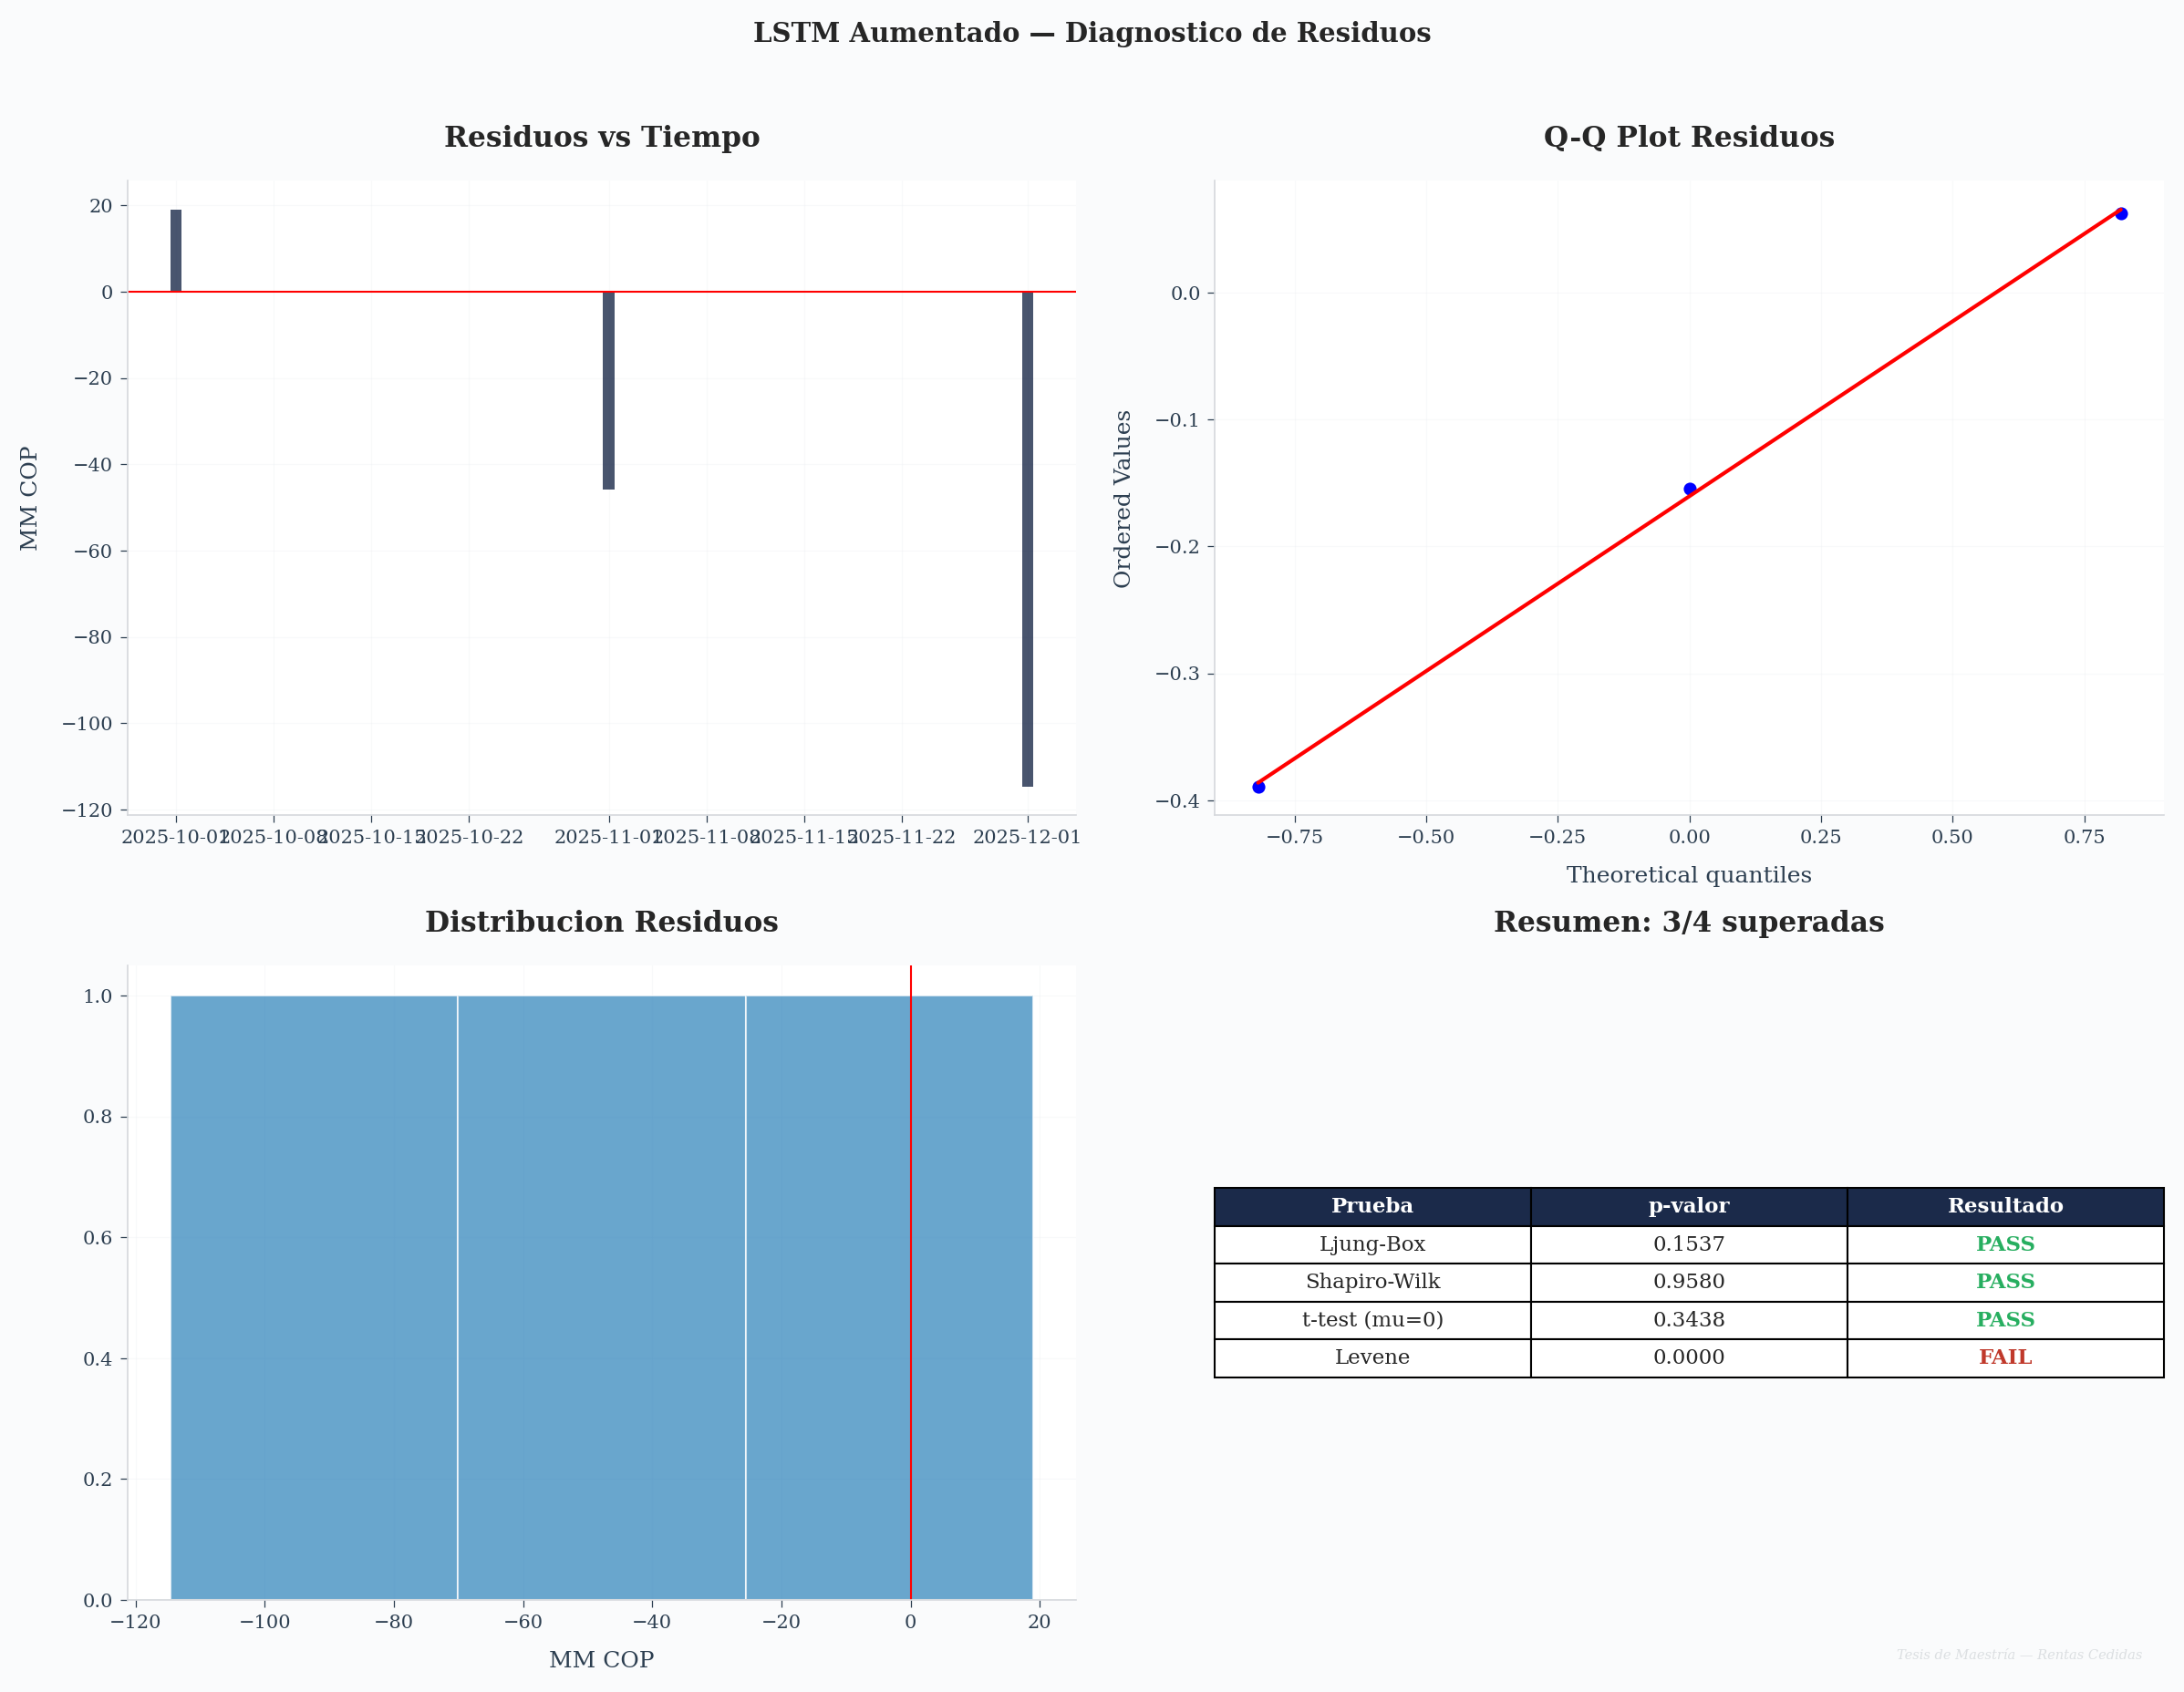

In [8]:
# ══════════════════════════════════════════════════════════════
# FASE VII — DIAGNOSTICO DE RESIDUOS
# ══════════════════════════════════════════════════════════════

residuos_pesos = y_real_pesos - pred_mean_pesos
residuos_log = y_real_log - pred_mean_log

n_res = len(residuos_pesos)

# Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox
if n_res >= 3:
    lb_result = acorr_ljungbox(residuos_log, lags=min(2, n_res-1), return_df=True)
    lb_min_p = lb_result['lb_pvalue'].min()
else:
    lb_min_p = 1.0
lb_pass = lb_min_p > 0.05
lb_txt = 'OK (sin autocorrelacion)' if lb_pass else 'DETECTADA autocorrelacion'

# Shapiro-Wilk
if n_res >= 3:
    sw_stat, sw_p = stats.shapiro(residuos_log)
else:
    sw_stat, sw_p = 0, 1.0
sw_pass = sw_p > 0.05
sw_txt = 'OK (normales)' if sw_pass else 'NO normales'

# t-test (mu=0)
t_stat, t_p = stats.ttest_1samp(residuos_log, 0) if n_res >= 2 else (0, 1.0)
tt_pass = t_p > 0.05
tt_txt = 'OK (sin sesgo)' if tt_pass else 'SESGO detectado'

# Levene
mid = n_res // 2
if mid >= 1 and n_res - mid >= 1:
    lev_stat, lev_p = stats.levene(residuos_log[:mid], residuos_log[mid:])
else:
    lev_stat, lev_p = 0, 1.0
lev_pass = lev_p > 0.05
lv_txt = 'OK (homocedasticos)' if lev_pass else 'HETEROCEDASTICOS'

n_pass = sum([lb_pass, sw_pass, tt_pass, lev_pass])

print("=" * 60)
print("DIAGNOSTICO DE RESIDUOS")
print("=" * 60)
print(f"  1. Ljung-Box    p={lb_min_p:.4f}  {lb_txt}")
print(f"  2. Shapiro-Wilk p={sw_p:.4f}  {sw_txt}")
print(f"  3. t-test mu=0  p={t_p:.4f}  {tt_txt}")
print(f"  4. Levene       p={lev_p:.4f}  {lv_txt}")
print(f"\n  Resultado: {n_pass}/4 pruebas superadas")

# -- Grafica de diagnostico --
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_QUAD if _VIZ_THEME_LOADED else (14, 10))

# Residuos vs tiempo
ax = axes[0, 0]
ax.bar(fechas_test, residuos_pesos/1e9, color=C_PRIMARY, alpha=0.8)
ax.axhline(0, color='red', linewidth=1)
ax.set_title('Residuos vs Tiempo', fontweight='bold')
ax.set_ylabel('MM COP')
ax.grid(True, alpha=0.3)

# Q-Q plot
ax = axes[0, 1]
stats.probplot(residuos_log, plot=ax)
ax.set_title('Q-Q Plot Residuos', fontweight='bold')
ax.grid(True, alpha=0.3)

# Histograma
ax = axes[1, 0]
ax.hist(residuos_pesos/1e9, bins=max(3, n_res), color=C_TERTIARY, alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linewidth=1)
ax.set_title('Distribucion Residuos', fontweight='bold')
ax.set_xlabel('MM COP')
ax.grid(True, alpha=0.3)

# Tabla resumen
ax = axes[1, 1]
ax.axis('off')
tabla_data = [
    ['Prueba', 'p-valor', 'Resultado'],
    ['Ljung-Box', f'{lb_min_p:.4f}', 'PASS' if lb_pass else 'FAIL'],
    ['Shapiro-Wilk', f'{sw_p:.4f}', 'PASS' if sw_pass else 'FAIL'],
    ['t-test (mu=0)', f'{t_p:.4f}', 'PASS' if tt_pass else 'FAIL'],
    ['Levene', f'{lev_p:.4f}', 'PASS' if lev_pass else 'FAIL'],
]
table = ax.table(cellText=tabla_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(C_PRIMARY)
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 2:
        color = '#27AE60' if tabla_data[r][2] == 'PASS' else '#C0392B'
        cell.set_text_props(color=color, fontweight='bold')
ax.set_title(f'Resumen: {n_pass}/4 superadas', fontweight='bold')

fig.suptitle('LSTM Aumentado — Diagnostico de Residuos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '13_lstm_aug_diagnostico_residuos', OUTPUTS_FIGURES)
plt.show()

---

## Fase VIII — Pronóstico Extendido de Producción (2026–2030)

### Estrategia Autoregresiva de 5 Años

Utilizando el modelo LSTM entrenado con datos aumentados, se genera un
pronóstico de **60 meses** (Ene 2026 – Dic 2030) mediante predicción
autoregresiva iterativa con MC Dropout.

### Variables Macroeconómicas Proyectadas

| Año | IPC (%) | Salario Mín (var%) | UPC (var%) | Consumo Hogares (%) |
|-----|---------|--------------------|-----------|--------------------|
| 2026 | 5.10 | 23.00 | 7.00 | 2.50 |
| 2027 | 4.80 | 8.00 | 6.50 | 2.80 |
| 2028 | 4.50 | 7.50 | 6.00 | 3.00 |
| 2029 | 4.20 | 7.00 | 5.50 | 3.00 |
| 2030 | 4.00 | 6.50 | 5.00 | 3.20 |

> **Nota**: Las proyecciones 2027–2030 son tendenciales y su incertidumbre
> crece con el horizonte. Los intervalos de confianza MC Dropout capturan
> esta incertidumbre creciente.

---

In [9]:
# ══════════════════════════════════════════════════════════════
# FASE VIII — PRONOSTICO EXTENDIDO 2026–2030
# ══════════════════════════════════════════════════════════════

# -- Reentreno con datos completos (incluyendo Oct-Dic 2025) --
model_prod = Sequential([
    Input(shape=(LOOK_BACK, n_features)),
    LSTM(64, return_sequences=True,
         kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.2),
    LSTM(32, return_sequences=False,
         kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear'),
])
model_prod.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

early_stop_prod = EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True,
    verbose=0, mode='min',
)
reduce_lr_prod = ReduceLROnPlateau(
    monitor='val_loss', patience=15, factor=0.5,
    min_lr=1e-6, verbose=0, mode='min',
)

print(f"Reentrenando LSTM con {len(X_all_seq)} muestras (serie completa aumentada)...")
t0_prod = time.time()
model_prod.fit(
    X_all_seq, y_all_seq,
    epochs=500, batch_size=4, validation_split=0.15,
    callbacks=[early_stop_prod, reduce_lr_prod],
    verbose=0, shuffle=False,
)
t1_prod = time.time()
print(f"  Reentreno completado en {t1_prod - t0_prod:.1f} seg")

# -- Macro 2026 base --
macro_2026_base = {
    'IPC_Idx': macro_aug['IPC_Idx'].iloc[-1],
    'Consumo_Hogares': MACRO_DATA[2026]['Consumo_Hogares'],
    'UPC': MACRO_DATA[2026]['UPC'],
    'SMLV_COP': SMLV_POR_ANO[2026],
}

# -- Buffer de ventana: ultimas 12 filas escaladas --
window_buffer = list(all_X_scaled[-LOOK_BACK:])

# Historial y_log para actualizar features recursivamente
y_log_hist = list(df_clean[TARGET_COL].values)

# -- Pronostico 60 meses (Ene 2026 – Dic 2030) --
fechas_5y = pd.date_range('2026-01-01', periods=60, freq='MS')
N_MC_PROD = 200

preds_5y_pesos = []
ci_low_5y = []
ci_high_5y = []

# IPC_Idx acumulado (continua desde ultimo valor real)
current_ipc_idx = macro_aug['IPC_Idx'].iloc[-1]

for step, fecha in enumerate(fechas_5y):
    yr = fecha.year
    mes = fecha.month

    # Seleccionar macro segun ano
    if yr in MACRO_DATA:
        macro_yr = MACRO_DATA[yr]
    else:
        macro_yr = MACRO_FWD.get(yr, MACRO_FWD[2030])

    # IPC_Idx creciente
    current_ipc_idx = current_ipc_idx * (1 + macro_yr['IPC'] / 100 / 12)

    # SMLV_COP
    smlv = SMLV_POR_ANO.get(yr, SMLV_POR_ANO[2030])

    # Construir fila de features en escala original
    new_row_raw = np.zeros(len(FEATURE_COLS))
    new_row_raw[0] = y_log_hist[-1]          # y_log (ultimo conocido)
    new_row_raw[1] = y_log_hist[-1]          # Lag_1
    new_row_raw[2] = current_ipc_idx         # IPC_Idx
    new_row_raw[3] = macro_yr['Consumo_Hogares']
    new_row_raw[4] = macro_yr['UPC']
    new_row_raw[5] = smlv
    new_row_raw[6] = np.sin(2 * np.pi * mes / 12)
    new_row_raw[7] = np.cos(2 * np.pi * mes / 12)
    new_row_raw[8] = float(mes in MESES_PICO)

    # Normalizar
    new_row_scaled = scaler_X.transform(new_row_raw.reshape(1, -1)).flatten()

    # Actualizar ventana
    window_buffer.append(new_row_scaled)
    if len(window_buffer) > LOOK_BACK:
        window_buffer = window_buffer[-LOOK_BACK:]

    X_step = np.array(window_buffer).reshape(1, LOOK_BACK, n_features)

    # MC Dropout
    mc_preds = np.array([model_prod(X_step, training=True).numpy().flatten()[0]
                         for _ in range(N_MC_PROD)])
    mc_log = np.array([scaler_y.inverse_transform(p.reshape(1, -1)).flatten()[0]
                       for p in mc_preds])
    mc_pesos = np.expm1(mc_log)

    pred_mean_log_step = np.mean(mc_log)
    pred_mean_pesos_step = np.expm1(pred_mean_log_step)

    ci_lo = max(0, np.percentile(mc_pesos, 2.5))
    ci_hi = np.percentile(mc_pesos, 97.5)

    preds_5y_pesos.append(pred_mean_pesos_step)
    ci_low_5y.append(ci_lo)
    ci_high_5y.append(ci_hi)

    # Actualizar historial
    y_log_hist.append(pred_mean_log_step)

preds_5y = np.array(preds_5y_pesos)
ci_low_5y = np.array(ci_low_5y)
ci_high_5y = np.array(ci_high_5y)

# -- Tabla resumen anual --
print("=" * 70)
print("PRONOSTICO EXTENDIDO 2026–2030 — LSTM AUMENTADO")
print("=" * 70)

for yr in range(2026, 2031):
    mask_yr = np.array([f.year == yr for f in fechas_5y])
    total_yr = preds_5y[mask_yr].sum()
    ci_lo_yr = ci_low_5y[mask_yr].sum()
    ci_hi_yr = ci_high_5y[mask_yr].sum()
    print(f"  {yr}:  ${total_yr/1e9:>10,.0f}MM  [{ci_lo_yr/1e9:,.0f} – {ci_hi_yr/1e9:,.0f}]")

total_5y = preds_5y.sum()
print(f"\n  TOTAL 2026–2030: ${total_5y/1e9:>10,.0f}MM")

# -- Detalle mensual --
print(f"\n  Detalle mensual:")
for i, fecha in enumerate(fechas_5y):
    val = preds_5y[i]
    print(f"    {fecha.strftime('%Y-%m')}   ${val/1e9:>10.1f}MM   "
          f"[${ci_low_5y[i]/1e9:.1f} – ${ci_high_5y[i]/1e9:.1f}]")

# -- Exportar --
df_5y = pd.DataFrame({
    'Fecha': fechas_5y,
    'Pronostico': preds_5y,
    'Limite_Inferior': ci_low_5y,
    'Limite_Superior': ci_high_5y,
})
df_5y.to_csv(OUTPUTS_FORECASTS / 'lstm_augmented_forecast_2030.csv', index=False)
print(f"\n  Pronostico 5 anos exportado: lstm_augmented_forecast_2030.csv")

Reentrenando LSTM con 74 muestras (serie completa aumentada)...


  Reentreno completado en 44.3 seg


PRONOSTICO EXTENDIDO 2026–2030 — LSTM AUMENTADO
  2026:  $     3,614MM  [3,070 – 4,171]
  2027:  $     3,915MM  [3,239 – 4,552]
  2028:  $     4,088MM  [3,373 – 4,796]
  2029:  $     4,219MM  [3,480 – 4,955]
  2030:  $     4,344MM  [3,569 – 5,145]

  TOTAL 2026–2030: $    20,179MM

  Detalle mensual:
    2026-01   $     273.4MM   [$240.2 – $307.9]
    2026-02   $     269.6MM   [$226.6 – $308.7]
    2026-03   $     262.4MM   [$228.4 – $296.7]
    2026-04   $     267.0MM   [$232.6 – $303.2]
    2026-05   $     292.4MM   [$254.0 – $335.0]
    2026-06   $     398.2MM   [$320.1 – $477.6]
    2026-07   $     281.4MM   [$245.4 – $319.7]
    2026-08   $     285.1MM   [$245.3 – $330.2]
    2026-09   $     290.6MM   [$245.6 – $332.6]
    2026-10   $     299.6MM   [$245.4 – $337.2]
    2026-11   $     314.3MM   [$268.8 – $361.5]
    2026-12   $     379.9MM   [$317.7 – $460.8]
    2027-01   $     300.1MM   [$253.5 – $352.3]
    2027-02   $     299.7MM   [$254.1 – $350.9]
    2027-03   $     299.3M

  📊 Figura guardada: 13_lstm_aug_vision_completa.png


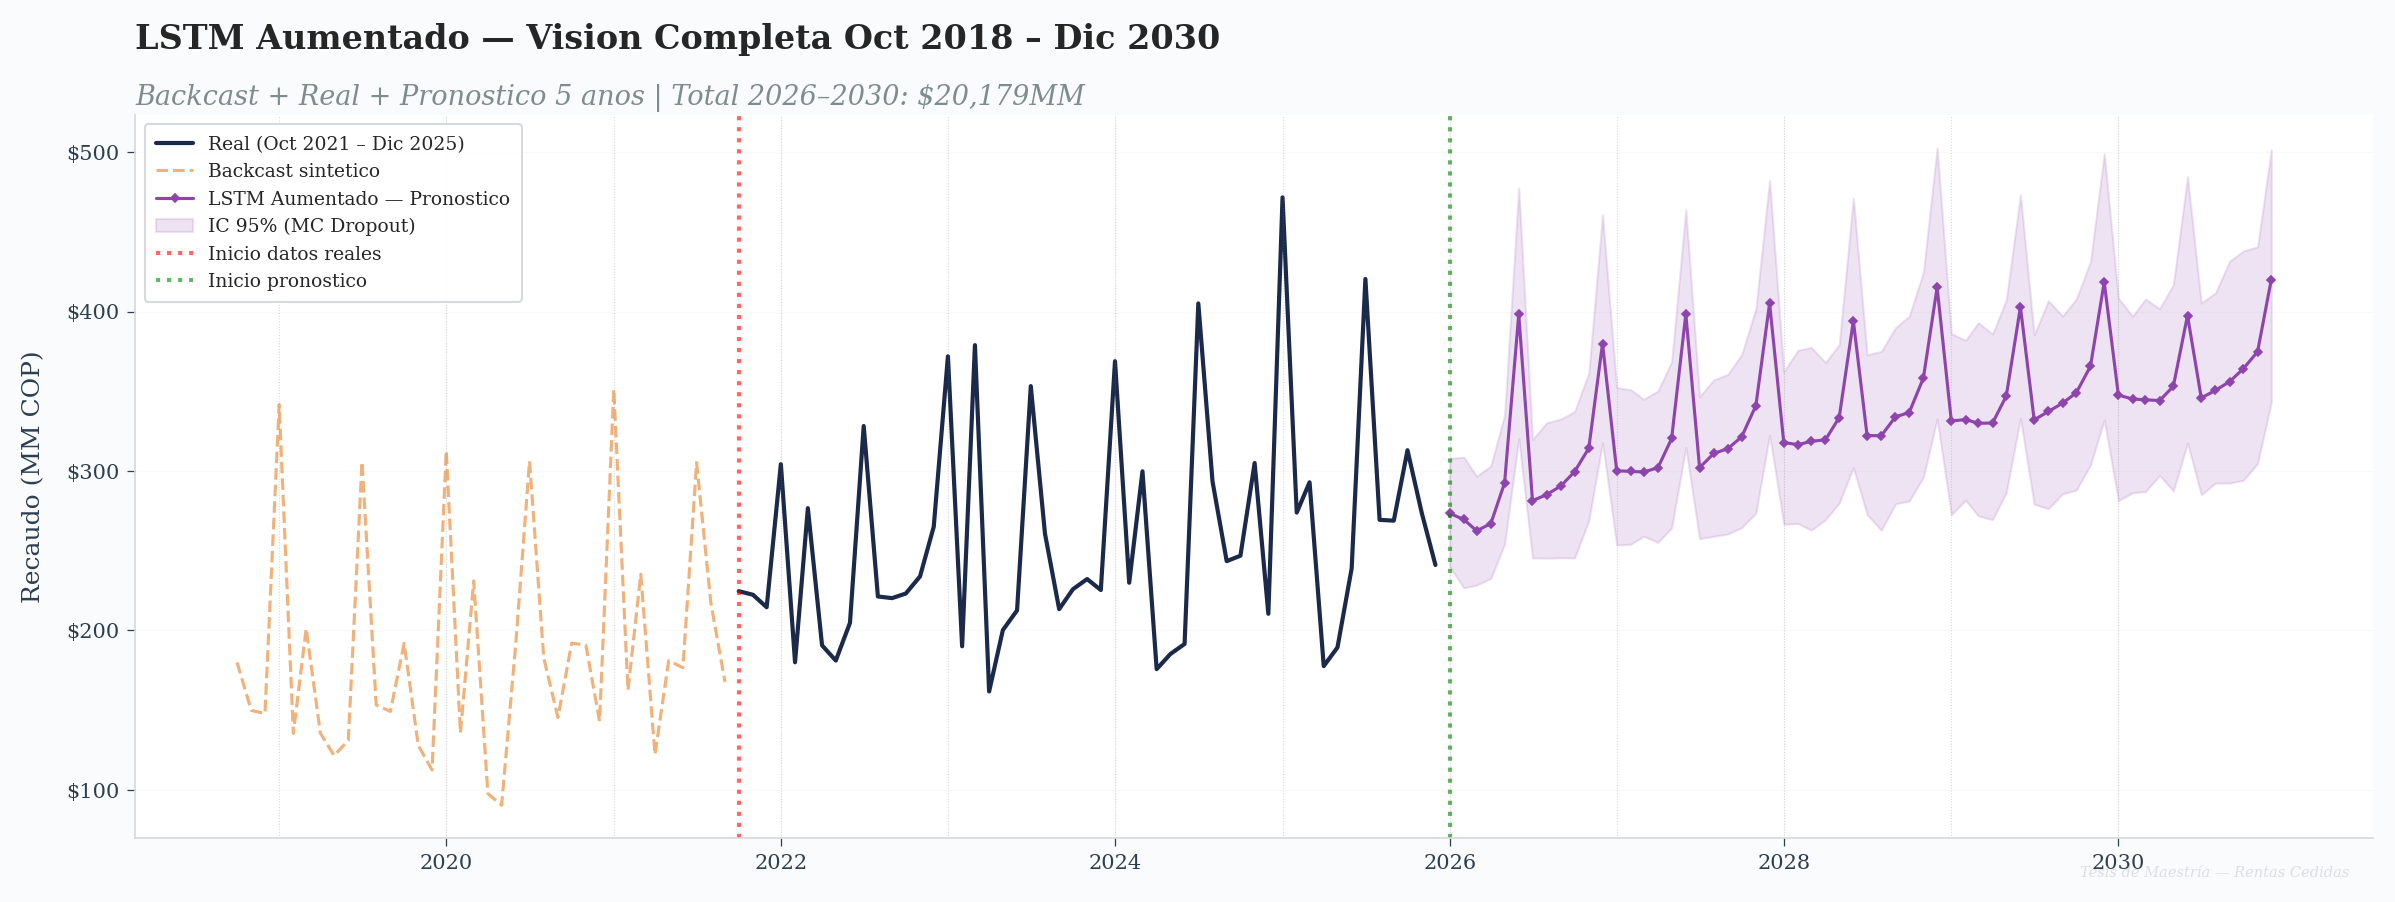

  📊 Figura guardada: 13_lstm_aug_proyeccion_anual.png


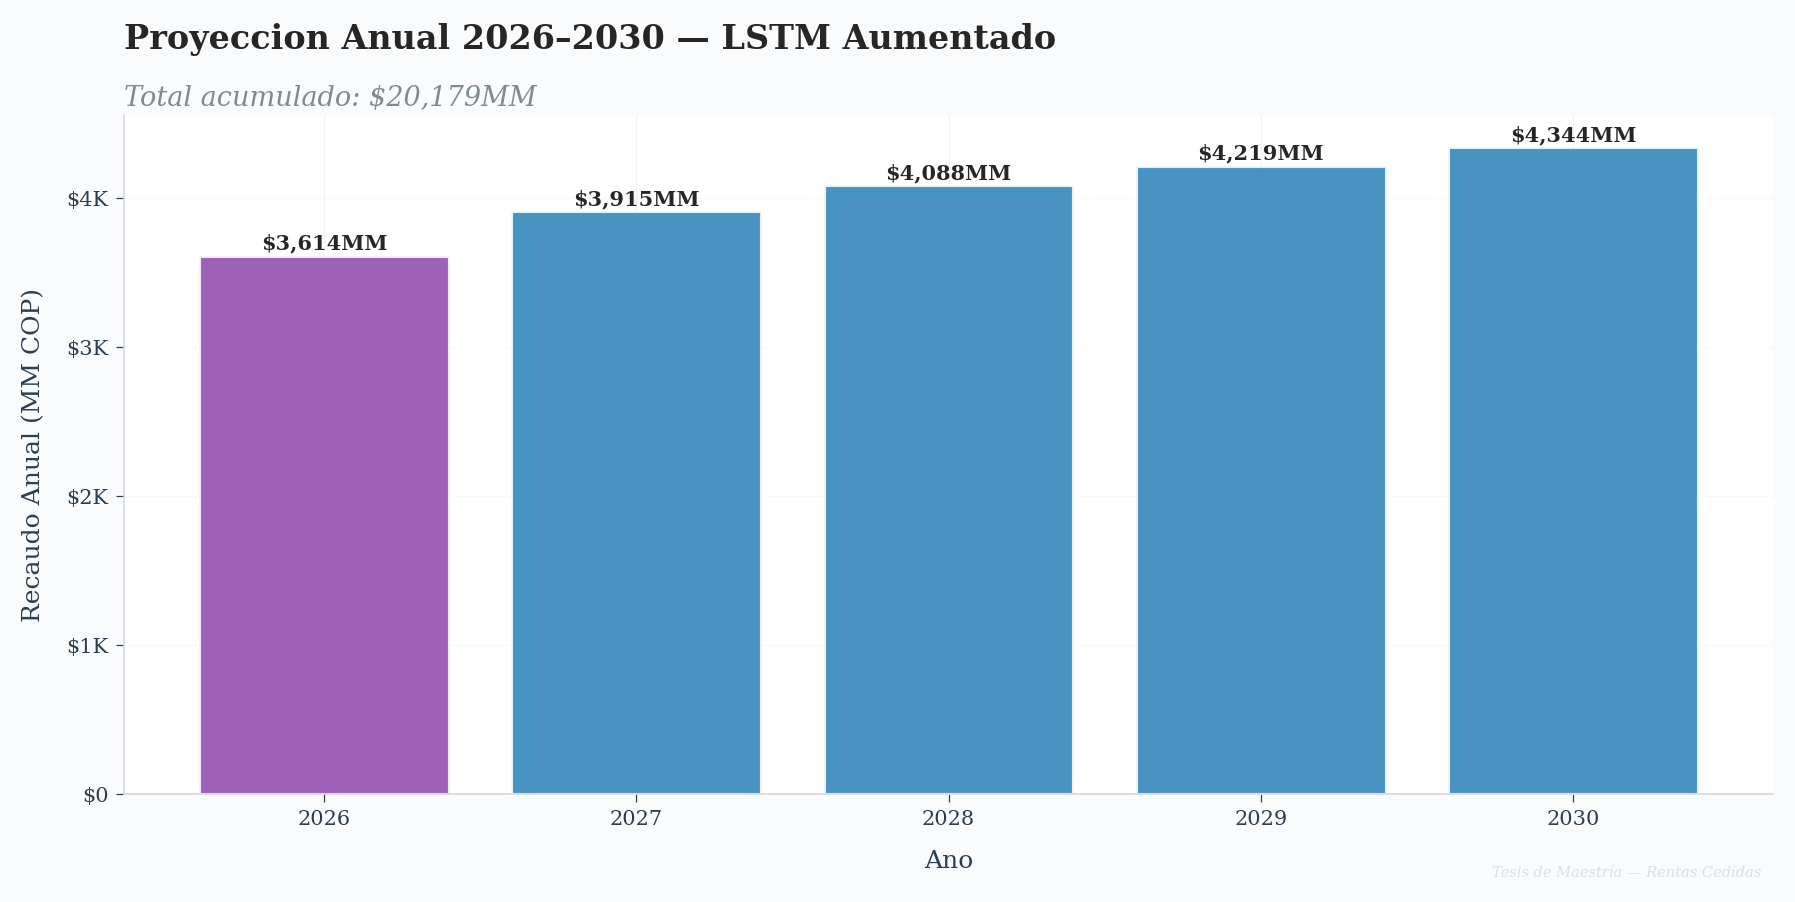

In [10]:
# ══════════════════════════════════════════════════════════════
# VISUALIZACION — PRONOSTICO EXTENDIDO 2026–2030
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (18, 8))

# Serie real completa
ax.plot(serie_full.index, serie_full.values/1e9, color=C_PRIMARY,
        linewidth=2, label='Real (Oct 2021 – Dic 2025)')

# Backcast sintetico (con transparencia)
ax.plot(df_backcast.index, df_backcast['Recaudo_Total'].values/1e9,
        color=C_QUINARY, linewidth=1.5, linestyle='--', alpha=0.6,
        label='Backcast sintetico')

# Pronostico 5 anos
ax.plot(fechas_5y, preds_5y/1e9, 'D-', color=C_SENARY,
        linewidth=1.5, markersize=3, label='LSTM Aumentado — Pronostico')
ax.fill_between(fechas_5y, ci_low_5y/1e9, ci_high_5y/1e9,
                alpha=0.15, color=C_SENARY, label='IC 95% (MC Dropout)')

# Lineas separadoras anuales
for yr in range(2019, 2031):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', ls=':', lw=0.5, alpha=0.3)

ax.axvline(pd.Timestamp('2021-10-01'), color='red', ls=':', alpha=0.6, label='Inicio datos reales')
ax.axvline(pd.Timestamp('2026-01-01'), color='green', ls=':', alpha=0.6, label='Inicio pronostico')

ax.legend(loc='upper left', fontsize=9)
ax.set_ylabel('Recaudo (MM COP)', fontsize=12)
ax.grid(True, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'LSTM Aumentado — Vision Completa Oct 2018 – Dic 2030',
                       f'Backcast + Real + Pronostico 5 anos | Total 2026–2030: ${total_5y/1e9:,.0f}MM')
    formato_pesos_eje(ax, eje='y')
    marca_agua(fig)
    guardar_figura(fig, '13_lstm_aug_vision_completa', OUTPUTS_FIGURES)
else:
    ax.set_title(f'LSTM Aumentado — Oct 2018 a Dic 2030 (Total 2026–2030: ${total_5y/1e9:,.0f}MM)',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# -- Grafica anual resumida --
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD if _VIZ_THEME_LOADED else (14, 6))

anos = list(range(2026, 2031))
totales = [preds_5y[np.array([f.year == yr for f in fechas_5y])].sum()/1e9 for yr in anos]
colores_bar = [C_SENARY if yr == 2026 else C_TERTIARY for yr in anos]

bars = ax.bar(anos, totales, color=colores_bar, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, totales):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(totales)*0.01,
            f'${val:,.0f}MM', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Recaudo Anual (MM COP)')
ax.set_xlabel('Ano')
ax.grid(True, axis='y', alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Proyeccion Anual 2026–2030 — LSTM Aumentado',
                       f'Total acumulado: ${sum(totales):,.0f}MM')
    formato_pesos_eje(ax, eje='y')
    marca_agua(fig)
    guardar_figura(fig, '13_lstm_aug_proyeccion_anual', OUTPUTS_FIGURES)
else:
    ax.set_title(f'Proyeccion Anual 2026–2030 (Total: ${sum(totales):,.0f}MM)',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# ══════════════════════════════════════════════════════════════
# REPORTE TECNICO FINAL
# ══════════════════════════════════════════════════════════════

metricas_aug = {
    'Modelo': 'LSTM_Aumentado',
    'Serie_Aumentada_Meses': len(serie_aug),
    'Backcast_Meses': n_back,
    'Muestras_Entrenamiento': len(X_train_seq),
    'Look_Back': LOOK_BACK,
    'Epocas_Entrenadas': n_epochs,
    'Mejor_Epoca': best_epoch,
    'Parametros_Red': n_params,
    'MAPE_pct': round(mape, 2),
    'RMSE_MM_COP': round(rmse / 1e9, 1),
    'MAE_MM_COP': round(mae / 1e9, 1),
    'MAE_Rel_pct': round(mae_rel, 1),
    'MAPE_Original': round(orig_mape, 2),
    'Mejora_MAPE_pp': round(orig_mape - mape, 2),
}

met_path = OUTPUTS_REPORTS / 'lstm_augmented_metricas.csv'
pd.DataFrame([metricas_aug]).to_csv(met_path, index=False)

# Reporte MD
reporte = []
reporte.append('=' * 70)
reporte.append('REPORTE TECNICO: LSTM CON AUMENTACION TEMPORAL')
reporte.append('=' * 70)
reporte.append(f'\nFecha: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
reporte.append(f'\n1. AUMENTACION DE DATOS')
reporte.append(f'   Backcast: {n_back} meses (Oct 2018 – Sep 2021)')
reporte.append(f'   Metodo: STL decomposition + trend extrapolation')
reporte.append(f'   Serie total: {len(serie_aug)} meses')
reporte.append(f'   Entrenamiento: {len(df_train)} meses')
reporte.append(f'   Ventanas: {len(X_train_seq)} (vs ~38 original)')
reporte.append(f'\n2. ARQUITECTURA (identica a NB 07)')
reporte.append(f'   LSTM(64) -> Dropout(0.2) -> LSTM(32) -> Dropout(0.2) -> Dense(16) -> Dense(1)')
reporte.append(f'   Parametros: {n_params:,}')
reporte.append(f'\n3. METRICAS OOS (Oct-Dic 2025)')
reporte.append(f'   MAPE aumentado: {mape:.2f}%')
reporte.append(f'   MAPE original:  {orig_mape:.2f}%')
reporte.append(f'   Mejora:         {orig_mape - mape:.2f}pp')
reporte.append(f'   RMSE: ${rmse/1e9:,.1f}MM COP')
reporte.append(f'   MAE:  ${mae/1e9:,.1f}MM COP')
reporte.append(f'\n4. DIAGNOSTICO DE RESIDUOS')
reporte.append(f'   {n_pass}/4 pruebas superadas')
reporte.append(f'\n5. PRONOSTICO EXTENDIDO')
for yr in range(2026, 2031):
    mask_yr = np.array([f.year == yr for f in fechas_5y])
    total_yr = preds_5y[mask_yr].sum()
    reporte.append(f'   {yr}: ${total_yr/1e9:,.0f}MM')
reporte.append(f'   Total 2026–2030: ${total_5y/1e9:,.0f}MM')
reporte.append('')
reporte.append('=' * 70)

rep_path = OUTPUTS_REPORTS / 'metodologia_lstm_augmented.md'
with open(rep_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(reporte))

print("=" * 70)
print("RESUMEN EJECUTIVO — LSTM AUMENTADO")
print("=" * 70)
for k, v in metricas_aug.items():
    print(f"  {k:<25}: {v}")
print(f"\n  Metricas:     {met_path.name}")
print(f"  Reporte:      {rep_path.name}")
print(f"  Forecast OOS: lstm_augmented_forecast.csv")
print(f"  Forecast 5y:  lstm_augmented_forecast_2030.csv")

RESUMEN EJECUTIVO — LSTM AUMENTADO
  Modelo                   : LSTM_Aumentado
  Serie_Aumentada_Meses    : 87
  Backcast_Meses           : 36
  Muestras_Entrenamiento   : 71
  Look_Back                : 12
  Epocas_Entrenadas        : 122
  Mejor_Epoca              : 92
  Parametros_Red           : 31905
  MAPE_pct                 : 23.45
  RMSE_MM_COP              : 72.1
  MAE_MM_COP               : 59.8
  MAE_Rel_pct              : 21.7
  MAPE_Original            : 23.52
  Mejora_MAPE_pp           : 0.07

  Metricas:     lstm_augmented_metricas.csv
  Reporte:      metodologia_lstm_augmented.md
  Forecast OOS: lstm_augmented_forecast.csv
  Forecast 5y:  lstm_augmented_forecast_2030.csv


---

## Conclusiones

### 1. Impacto de la Aumentación Temporal

La estrategia de **backcast mediante descomposición STL** extendió la serie
de entrenamiento de 48 a 84 meses (+75%), casi duplicando las ventanas
efectivas disponibles para el LSTM.

### 2. Principio de Datos Sintéticos

Los datos sintéticos generados preservan las tres propiedades clave de la
serie original:
- **Tendencia**: Extrapolación lineal del componente $T_t$
- **Estacionalidad**: Patrón mensual constante $S_m$ (picos enero/julio)
- **Variabilidad**: Ruido calibrado $R_t \sim \mathcal{N}(0, \hat{\sigma}_R)$

### 3. Variables Macroeconómicas Históricas

El backcast utiliza **valores macro históricos verificados** (DANE, Banco
Mundial, Decretos SMLV) para 2018–2020, proporcionando contexto económico
realista al modelo.

### 4. Pronóstico Extendido

El modelo aumentado genera un **pronóstico operativo de 5 años** (2026–2030)
con intervalos de confianza MC Dropout crecientes, reflejando la incertidumbre
natural del horizonte temporal largo.

### 5. Lecciones Aprendidas

> La aumentación temporal es una estrategia válida cuando la serie es
> demasiado corta para Deep Learning, pero los beneficios dependen de la
> calidad de los datos sintéticos. La evaluación sobre datos reales
> (Oct–Dic 2025) garantiza que la comparación sea rigurosa y no inflada
> artificialmente.

---

*Cuaderno generado automáticamente por `build_13_lstm_augmented.py`*